### Analyze Post-Optimization results for a single run 

**stochastic model with scenario tree for long-term demand uncertainty and using only a subset of weeks each representative year**

# Data reading and setup

In [108]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [109]:
# Now this works because Python sees `src` as a top-level module
from src import analytics, plotting, utils

In [110]:
import yaml

In [111]:
# Notebook input parameters
SAVE_FIGURES = False
SAVE_TABLES = False
show_plots = False
folder_name = "XXX4weeks_1core___"

In [112]:
FOLDER = os.path.join(
    os.path.dirname(os.getcwd()),
    "runs",
    "single_runs",
    folder_name,
)
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\1_May16_Fri_h23_m07_s45-GTSEP_stochastic_v1-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\2_May17_Sat_h00_m00_s46-GTSEP_stochastic_v1-128_ES_PT_no_bat"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\single_runs\May22_Thu_h13_m45_s00-GTSEP_stochastic_v1-37_ES_PT"
decision_variables_folder = os.path.join(FOLDER, "decision_variables")
model_info_folder = os.path.join(FOLDER, "model_info")
dual_variables_folder = os.path.join(FOLDER, "dual_variables")

In [113]:
RESULTS_FOLDER = os.path.join(FOLDER, "results")
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)
if SAVE_TABLES:
    tables_folder = os.path.join(RESULTS_FOLDER, "tables")
    if not os.path.exists(tables_folder):
        os.makedirs(tables_folder)
else:
    tables_folder = None
if SAVE_FIGURES:
    figures_folder = os.path.join(RESULTS_FOLDER, "figures")
    if not os.path.exists(figures_folder):
        os.makedirs(figures_folder)
else:
    figures_folder = None

In [114]:
# Color mapping for scenarios (reuse for other plots)
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#cc79a7",  # magenta
    "Curtailment Cost": "#56b4e9",  # light blue
}

## Read data

In [115]:
model_info = pd.read_csv(os.path.join(model_info_folder, "model_info.csv"))
config = yaml.safe_load(open(os.path.join(model_info_folder, "config.yaml")))
jsons = utils.read_jsons_from_dir(model_info_folder)

In [116]:
scenarios = jsons["scenarios"]
scenario_probabilities = jsons["scenario_probabilities"]
week_weights = jsons["week_weights"]

In [117]:
data_folder_name = config["data_folder_name"]
VOLL = config["VOLL"]
CC = config["CC"]
CO2_price = config["CO2_price"]
E_limit = config["E_limit"]
p_max_new_branch = config["p_max_new_branch"]
p_min_new_branch = config["p_min_new_branch"]
expansion_factor = config["expansion_factor"]
MS = config["MS"]
model_name = config["model_name"]
MIPGap = config["MIPGap"]
years = config["years"]
r = config["discount_rate"]
representative_period_unit = config["representative_period_unit"]
weeks = config["representative_periods"]
scenario_file = config["scenario_file"]

In [118]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
)
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years=years, data_folder_path=input_data_folder
)
scenario_multiplier = utils.load_scenario_multiplier(scenario_file_name=scenario_file)

**Note:** The input data is such that all data is the same for all years. All the data that is year-dependent has year as index. The only exception is the demand data, which does not have copies for years.

In [119]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_folder)
decision_varables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_folder
)

In [120]:
print("Input data")
for data_type in input_data.keys():
    print(f"{data_type}")
print()
print("Decision variables:")
for decision_variable in decision_varables.keys():
    print(decision_variable)
print()
print("Dual variables:")
for dual_variable in dual_variables.keys():
    print(dual_variable)

Input data
batteries
branches
capacity_factors
generators
generator_costs
hourly_demand
nodes

Decision variables:
battery_capacity
battery_charging
battery_discharging
battery_soc
branch_capacity
curtailment
generation
generator_capacity
load_shedding
power_flow

Dual variables:
battery_charge_new_max_duals
battery_charge_old_duals
battery_discharge_new_max_duals
battery_discharge_old_duals
branch_extension_duals
branch_flow_new_duals_max
branch_flow_new_duals_min
branch_flow_old_duals_max
branch_flow_old_duals_min
emissions_duals
gen_extension_duals
gen_output_new_duals
gen_output_old_duals
load_shedding_duals
power_balance_duals


In [122]:
decision_varables

{'battery_capacity':                        value
 battery   year              
 ES1 0 bat 2025      0.000000
           2030      0.000000
           2040   1307.695166
           2050   7627.027940
 PT1 0 bat 2025      0.000000
           2030      0.000000
           2040  13226.363857
           2050  24988.328158,
 'battery_charging':                                    value
 battery   scenario year week hour       
 ES1 0 bat NT       2025 21   0       0.0
                              1       0.0
                              2       0.0
                              3       0.0
                              4       0.0
 ...                                  ...
 PT1 0 bat DE       2050 42   163     0.0
                              164     0.0
                              165     0.0
                              166     0.0
                              167     0.0
 
 [4704 rows x 1 columns],
 'battery_discharging':                                          value
 battery   sce

In [ ]:
# read dataframes
# input data
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
# decision variables
battery_capacity = decision_varables["battery_capacity"]
battery_charging = decision_varables["battery_charging"]
battery_discharging = decision_varables["battery_discharging"]
battery_soc = decision_varables["battery_soc"]
branch_capacity = decision_varables["branch_capacity"]
curtailment = decision_varables["curtailment"]
generation = decision_varables["generation"]
generator_capacity = decision_varables["generator_capacity"]
load_shedding = decision_varables["load_shedding"]
power_flow = decision_varables["power_flow"]

## Generators analysis

### Generators preprocessing

In [ ]:
generators["extension_potential"] = generators["p_nom"] * config["expansion_factor"]

In [ ]:
# Example usage:
generators = analytics.add_capacity_and_cumulative_metrics(
    generators, generator_capacity
)

In [ ]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,52610.664000,26305.332000
2030,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,105221.328000,26305.332000
2040,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,157831.992000,26305.332000
2050,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,210442.656000,26305.332000
2025,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,9478.786965,4739.393483
2030,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,18957.573931,4739.393483
2040,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,28436.360896,4739.393483
2050,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,37915.147862,4739.393483
2025,ES1 0 offwind-ac,ES1 0,offwind-ac,9274.463486,0.015000,184160.119456,0.00,#6895dd,Offshore Wind (AC),True,18548.926971,18548.926971,18548.926971,18548.926971,27823.390457


### Generator Investment and Capacity Plots 

In [ ]:
if SAVE_FIGURES:
    generators_save_folder = os.path.join(figures_folder, "generators")
    if not os.path.exists(generators_save_folder):
        os.makedirs(generators_save_folder)
else:
    generators_save_folder = None

if SAVE_TABLES:
    generators_save_table_folder = os.path.join(tables_folder, "generators")
    if not os.path.exists(generators_save_table_folder):
        os.makedirs(generators_save_table_folder)
else:
    generators_save_table_folder = None

Annual Capacity Investments by Technology


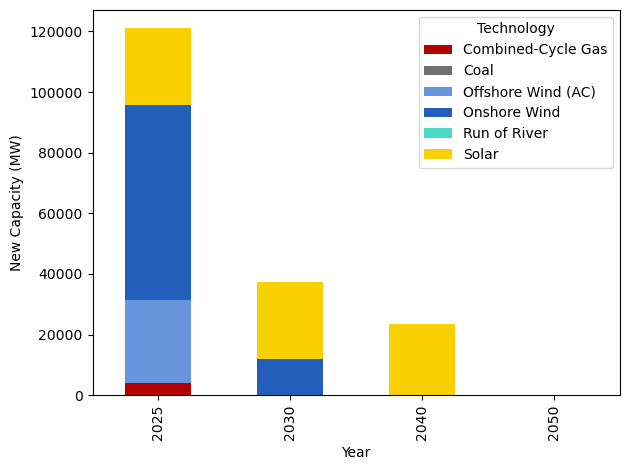

In [ ]:
analytics.plot_capacity_investment_by_carrier(generators, generators_save_folder)

Annual Capital Expenditure by Technology


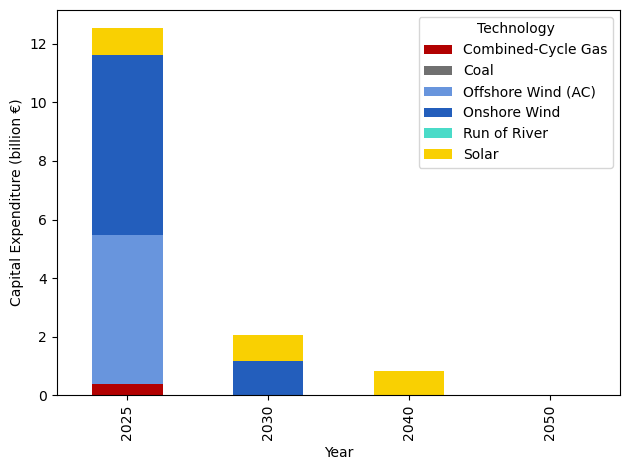

In [ ]:
analytics.plot_capacity_spending_by_carrier(generators, generators_save_folder)

Growth in Total Installed Capacity


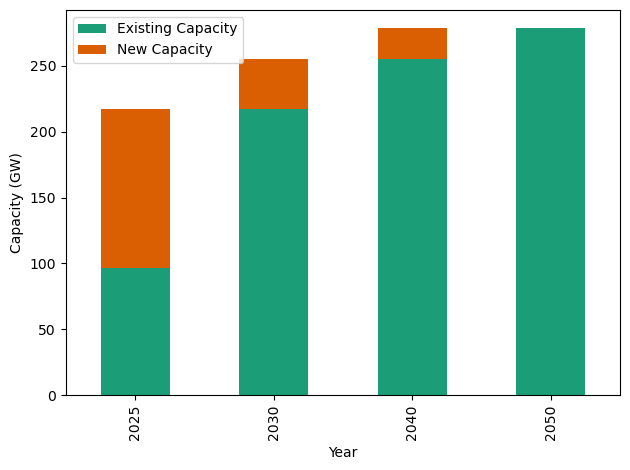

In [ ]:
analytics.plot_total_capacity_growth(generators, generators_save_folder)

Extension Potential vs Actual New Capacity by Technology


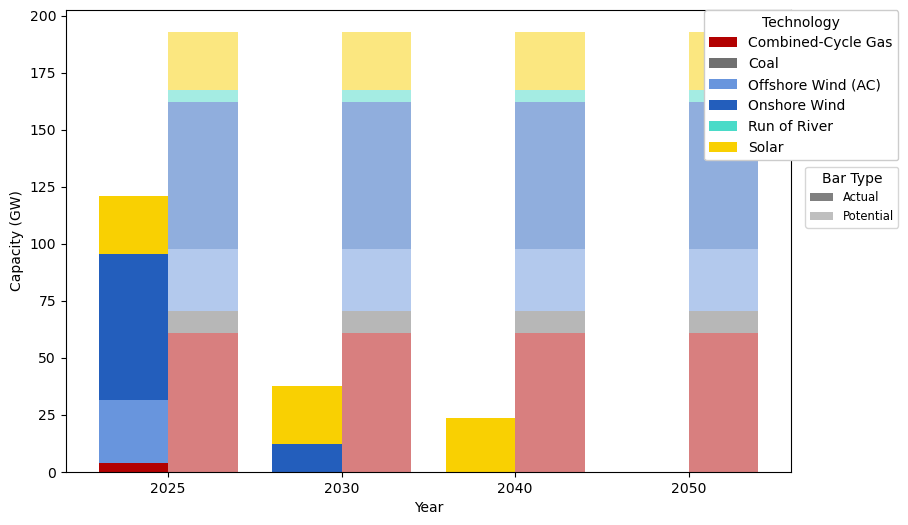

In [ ]:
analytics.plot_extension_vs_potential_by_carrier(generators, generators_save_folder)

### Generators Production and Time Series Plots

In [ ]:
production_by_carrier_table = analytics.create_energy_production_by_carrier_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    savefolder=generators_save_table_folder,
)
production_by_carrier_table


Annual expected energy production by carrier (scenario-weighted):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar
year,,,,,,
2025,4.685813e+07,1.069384e+07,6.731782e+07,8.239676e+07,4.195184e+06,6.110856e+07
2030,4.308329e+07,8.969400e+06,5.858354e+07,8.034833e+07,4.195184e+06,9.696186e+07
2040,5.915032e+07,1.309973e+07,5.545762e+07,8.652111e+07,4.195184e+06,1.289209e+08
2050,6.629514e+07,1.489477e+07,5.817984e+07,9.165511e+07,4.195184e+06,1.341419e+08


In [ ]:
annual_production_table = analytics.make_annual_production_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
annual_production_table

Annual expected energy production by carrier and scenario (MWh):


carrier                CCGT          coal    offwind-ac        onwind  \
year scenario                                                           
2025 NT        4.685813e+07  1.069384e+07  6.731782e+07  8.239676e+07   
2030 NT        4.308329e+07  8.969400e+06  5.858354e+07  8.034833e+07   
2040 DE        2.201878e+07  5.146493e+06  1.904499e+07  2.969564e+07   
     GA        1.633154e+07  3.276600e+06  1.762398e+07  2.760075e+07   
     NT        2.079999e+07  4.676634e+06  1.878865e+07  2.922473e+07   
2050 DE        3.825323e+07  9.290396e+06  2.993276e+07  4.782072e+07   
     GA        2.804192e+07  5.604373e+06  2.824709e+07  4.383439e+07   

carrier                 ror         solar         Total  
year scenario                                            
2025 NT        4.195184e+06  6.110856e+07  2.725703e+08  
2030 NT        4.195184e+06  9.696186e+07  2.921416e+08  
2040 DE        1.398395e+06  4.379083e+07  1.210951e+08  
     GA        1.398395e+06  4.173240e+07  1.079637e+08  
     NT        1.398395e+06  4.339766e+07  1.182861e+08  
2050 DE        2.097592e+06  6.815706e+07  1.955517e+08  
     GA        2.097592e+06  6.598480e+07  1.738102e+08

In [ ]:
annual_cost_table = analytics.make_weighted_annual_production_cost_by_year_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    carbon_price=CO2_price,
    savefolder=generators_save_table_folder,
)
annual_cost_table

Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,2.597404e+09,5.924061e+08,1.009767e+06,1.235951e+06,0.0,6.110856e+05,3.192667e+09
2030,2.391321e+09,4.968776e+08,8.787531e+05,1.205225e+06,0.0,9.696186e+05,2.891253e+09
2040,3.290054e+09,7.256852e+08,8.318643e+05,1.297817e+06,0.0,1.289209e+06,4.019158e+09
2050,3.691040e+09,8.251250e+08,8.726976e+05,1.374827e+06,0.0,1.341419e+06,4.519754e+09


In [ ]:
weighted_annual_production_by_year = analytics.make_weighted_annual_production_by_year(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
weighted_annual_production_by_year

Annual scenario-weighted energy production by carrier (MWh):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,4.685813e+07,1.069384e+07,6.731782e+07,8.239676e+07,4.195184e+06,6.110856e+07,2.725703e+08
2030,4.308329e+07,8.969400e+06,5.858354e+07,8.034833e+07,4.195184e+06,9.696186e+07,2.921416e+08
2040,5.915032e+07,1.309973e+07,5.545762e+07,8.652111e+07,4.195184e+06,1.289209e+08,3.473449e+08
2050,6.629514e+07,1.489477e+07,5.817984e+07,9.165511e+07,4.195184e+06,1.341419e+08,3.693619e+08


Evolution of Annual Energy Production by Technology (averaged across scenarios)


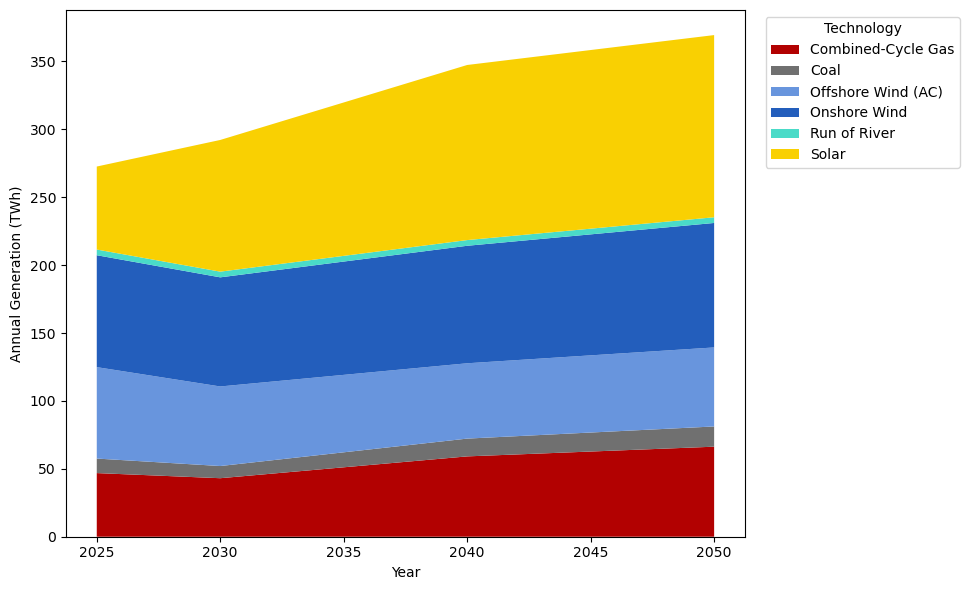

Evolution of Annual Energy Production by Technology (averaged across scenarios)


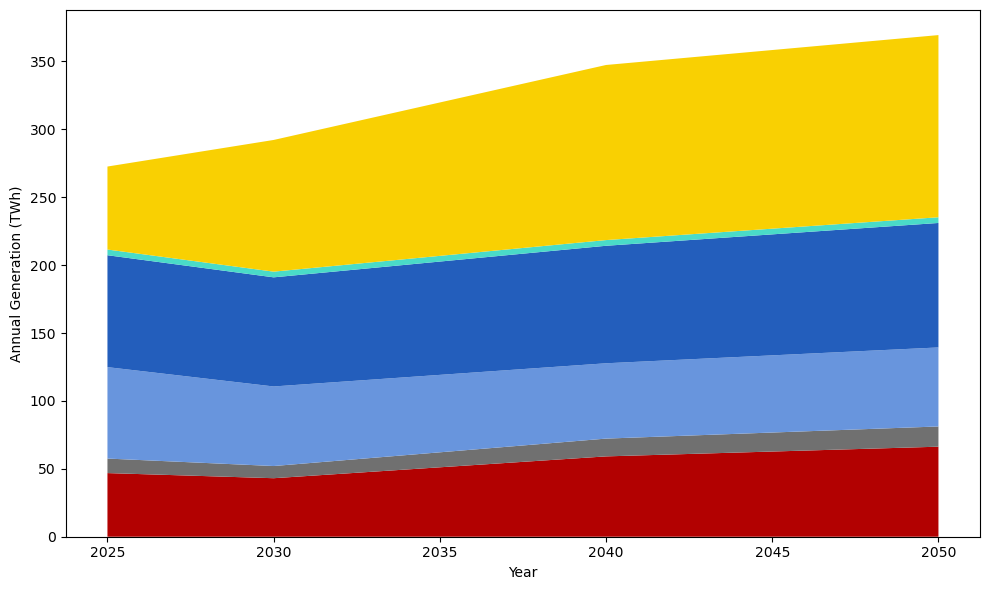

In [ ]:
analytics.plot_weighted_production_evolution(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

analytics.plot_weighted_production_evolution_no_legend(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

Evolution of Annual Production Cost including CO₂ Emissions by Technology


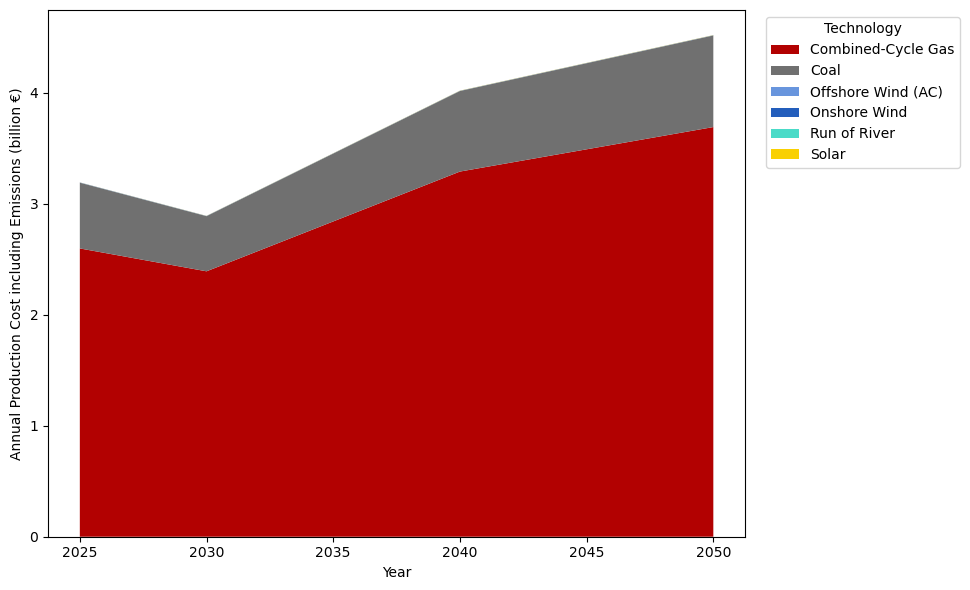

In [ ]:
analytics.plot_weighted_production_cost_evolution(
    annual_cost_table, generators, savefolder=generators_save_folder
)

In [ ]:
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, generators_save_table_folder
)
yearly_system_cost_table

Yearly system metrics by year and scenario:


production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.725703e+08  1.300753e+07       1.040602e+09     2.152064e+09   
2030 NT        2.921416e+08  1.166625e+07       9.333003e+08     1.957952e+09   
2040 DE        3.632854e+08  1.846069e+07       1.476855e+09     3.058474e+09   
     GA        3.238910e+08  1.314106e+07       1.051285e+09     2.218599e+09   
     NT        3.548582e+08  1.725016e+07       1.380013e+09     2.872248e+09   
2050 DE        3.911035e+08  2.161876e+07       1.729501e+09     3.566437e+09   
     GA        3.476203e+08  1.502774e+07       1.202219e+09     2.541351e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         3.192667e+09  
2030 NT                         2.891253e+09  
2040 DE                         4.535329e+09  
     GA                         3.269883e+09  
     NT                         4.252261e+09  
2050 DE                         5.295937e+09  
     GA                         3.743571e+09

CO₂ Emissions by Year and Scenario


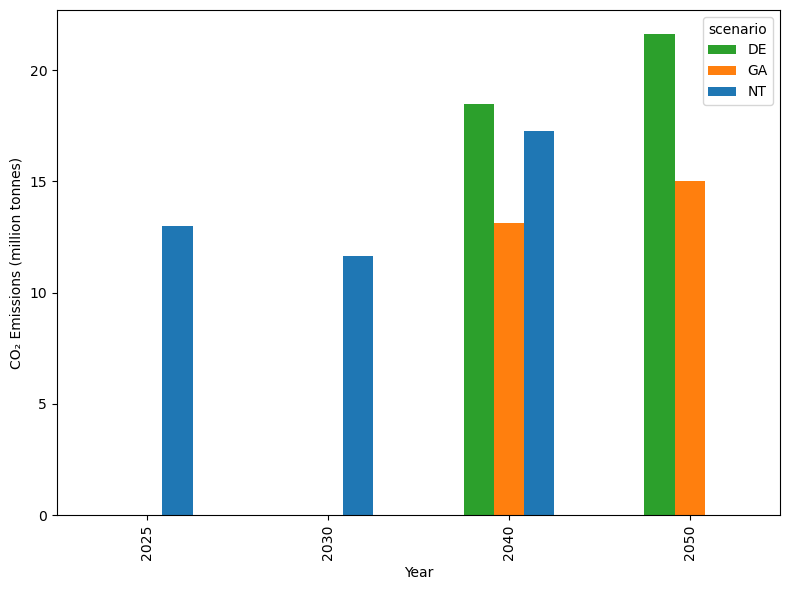

CO₂ Emissions by Year, Scenario, and Average


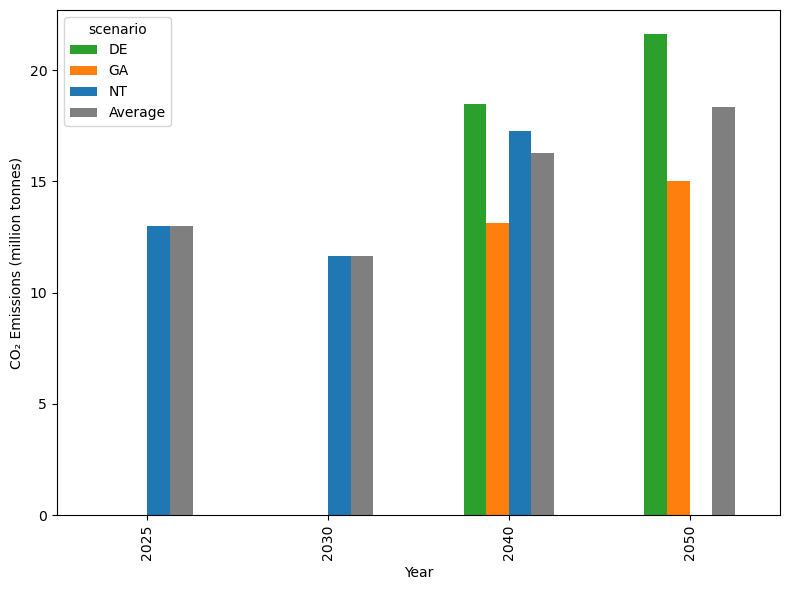

Annual Production by Year, Scenario, and Average


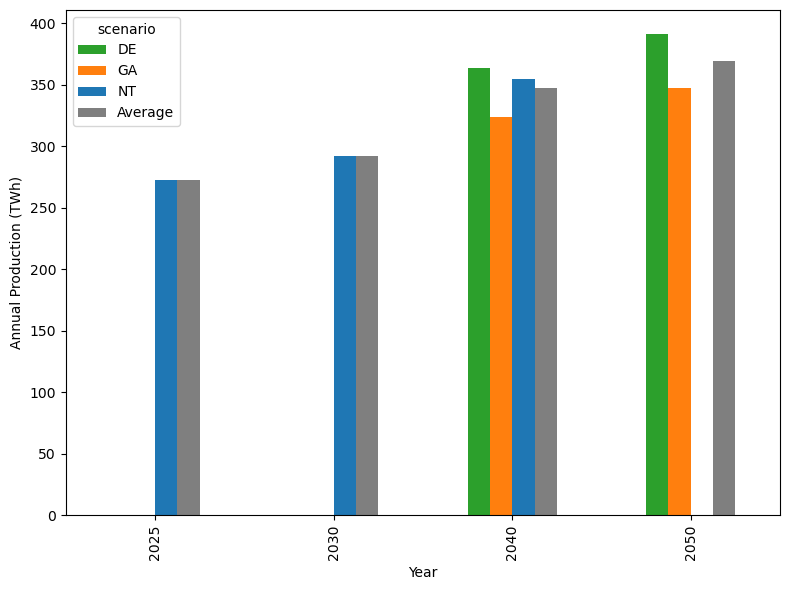

Production Cost by Year, Scenario, and Average


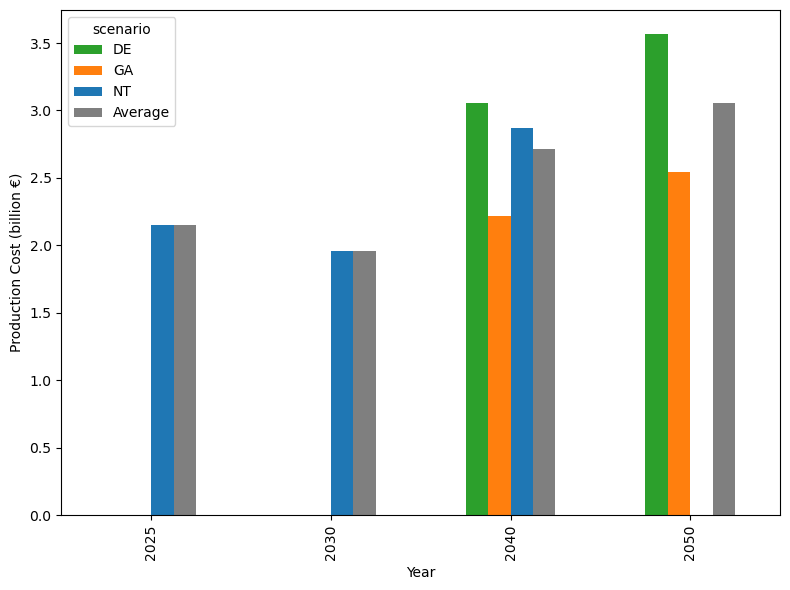

Production Cost w/ Emissions by Year, Scenario, and Average


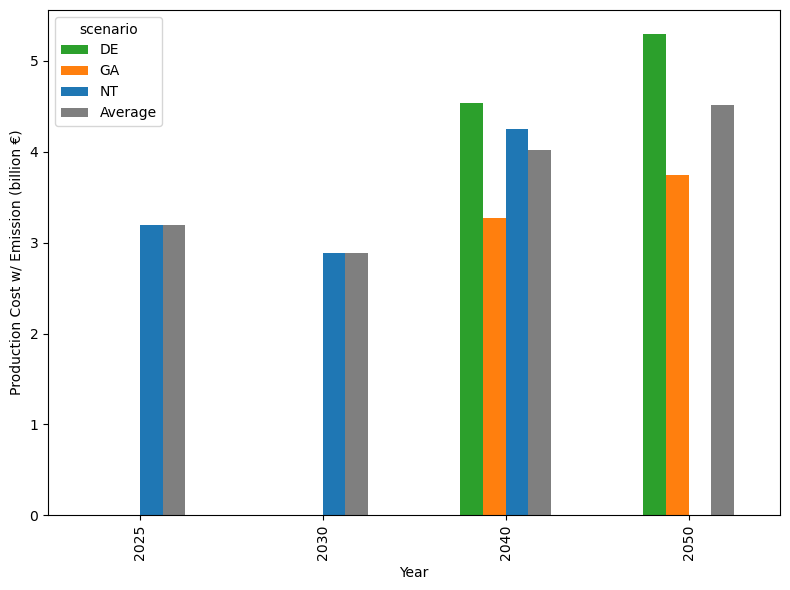

In [ ]:
analytics.plot_co2_emissions_by_scenario(
    yearly_system_cost_table, savefolder=generators_save_folder
)
analytics.plot_co2_emissions_by_scenario_avg(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_by_scenario(yearly_system_cost_table, generators_save_folder)
analytics.plot_production_cost_by_scenario(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_cost_with_emission_by_scenario(
    yearly_system_cost_table, generators_save_folder
)

In [ ]:
# if figures_folder:
#     generation_curves_folder = os.path.join(figures_folder, "generation_curves")
#     os.makedirs(generation_curves_folder, exist_ok=True)
# else:
#     generation_curves_folder = None

# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()

# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 analytics.plot_fraction_of_max_generation_by_carrier(
#                     generation,
#                     capacity_factors,
#                     generators,
#                     year,
#                     week,
#                     scen,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
#                 )

In [ ]:
# # loop over combinations
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             analytics.plot_utilization_time_series_by_carrier(
#                 generation,
#                 capacity_factors,
#                 generators,
#                 year,
#                 week,
#                 scen,
#                 savefolder=tables_folder,
#             )

In [ ]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,52610.664000,26305.332000
2030,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,105221.328000,26305.332000
2040,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,157831.992000,26305.332000
2050,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,210442.656000,26305.332000
2025,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,9478.786965,4739.393483
2030,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,18957.573931,4739.393483
2040,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,28436.360896,4739.393483
2050,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,37915.147862,4739.393483
2025,ES1 0 offwind-ac,ES1 0,offwind-ac,9274.463486,0.015000,184160.119456,0.00,#6895dd,Offshore Wind (AC),True,18548.926971,18548.926971,18548.926971,18548.926971,27823.390457


Annual Utilization Factor by Year, Scenario, and Carrier


c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2481: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2482: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier


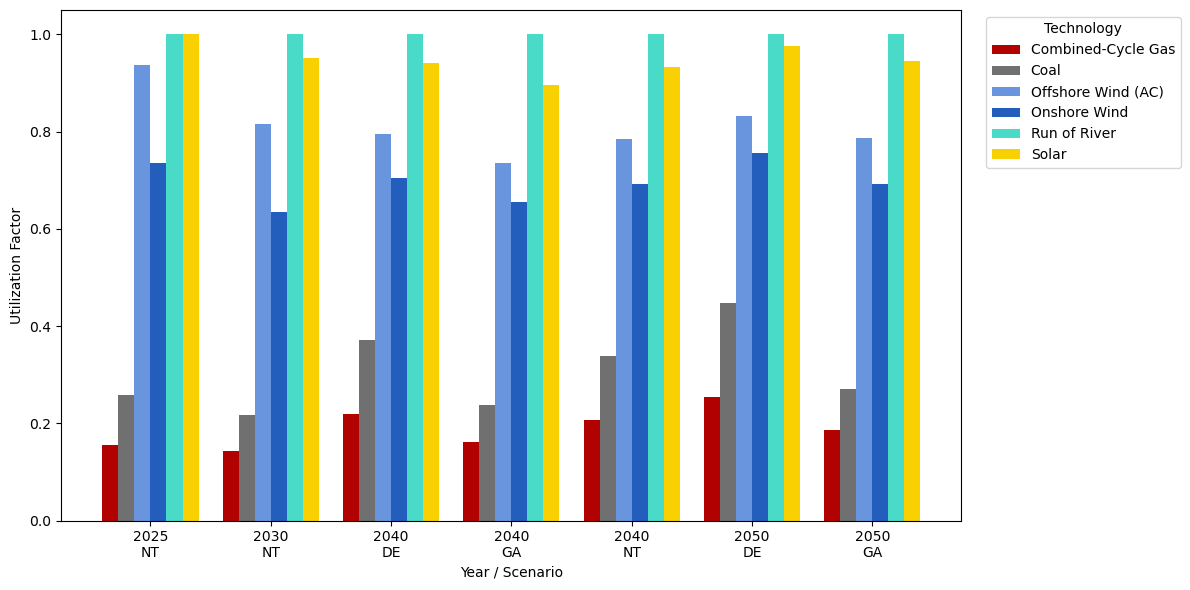

In [ ]:
analytics.plot_utilization_hierarchy(
    generation,
    capacity_factors,
    generators,
    week_weights,
    scenarios,
    savefolder=generators_save_folder,
)

In [ ]:
summary_table = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)

In [ ]:
summary_table

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,192912.81714,121000.945632,11,7,1.252836e+10,2.725703e+08,1.300753e+07,1.040602e+09,2.152064e+09,3.192667e+09,1.572103e+10
2030,192912.81714,37437.358670,11,3,2.060064e+09,2.921416e+08,1.166625e+07,9.333003e+08,1.957952e+09,2.891253e+09,4.951316e+09
2040,192912.81714,23540.312508,11,2,8.380839e+08,3.473449e+08,1.628397e+07,1.302718e+09,2.716440e+09,4.019158e+09,4.857242e+09
2050,192912.81714,0.000000,11,0,0.000000e+00,3.693619e+08,1.832325e+07,1.465860e+09,3.053894e+09,4.519754e+09,4.519754e+09


In [ ]:
summary_by_carrier_table = analytics.make_system_summary_table_by_carrier(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    tables_folder,
)
summary_by_carrier_table

potential_capacity  new_capacity  number_possible_buildouts  \
year carrier                                                                   
2025 CCGT              60900.664000   4038.595953                          2   
     coal               9478.786965      0.000000                          1   
     offwind-ac        27469.304444  27469.304444                          2   
     onwind            64079.006689  64079.006689                          2   
     ror                5571.016495      0.000000                          2   
     solar             25414.038546  25414.038546                          2   
2030 CCGT              60900.664000      0.000000                          2   
     coal               9478.786965      0.000000                          1   
     offwind-ac        27469.304444      0.000000                          2   
     onwind            64079.006689  12023.320124                          2   
     ror                5571.016495      0.000000                          2   
     solar             25414.038546  25414.038546                          2   
2040 CCGT              60900.664000      0.000000                          2   
     coal               9478.786965      0.000000                          1   
     offwind-ac        27469.304444      0.000000                          2   
     onwind            64079.006689      0.000000                          2   
     ror                5571.016495      0.000000                          2   
     solar             25414.038546  23540.312508                          2   
2050 CCGT              60900.664000      0.000000                          2   
     coal               9478.786965      0.000000                          1   
     offwind-ac        27469.304444      0.000000                          2   
     onwind            64079.006689      0.000000                          2   
     ror                5571.016495      0.000000                          2   
     solar             25414.038546      0.000000                          2   

                 number_actual_buildouts  cost_of_buildout  total_production  \
year carrier                                                                   
2025 CCGT                              1      3.999330e+08      4.685813e+07   
     coal                              0      0.000000e+00      1.069384e+07   
     offwind-ac                        2      5.066546e+09      6.731782e+07   
     onwind                            2      6.157088e+09      8.239676e+07   
     ror                               0      0.000000e+00      4.195184e+06   
     solar                             2      9.047924e+08      6.110856e+07   
2030 CCGT                              0      0.000000e+00      4.308329e+07   
     coal                              0      0.000000e+00      8.969400e+06   
     offwind-ac                        0      0.000000e+00      5.858354e+07   
     onwind                            1      1.155271e+09      8.034833e+07   
     ror                               0      0.000000e+00      4.195184e+06   
     solar                             2      9.047924e+08      9.696186e+07   
2040 CCGT                              0      0.000000e+00      5.915032e+07   
     coal                              0      0.000000e+00      1.309973e+07   
     offwind-ac                        0      0.000000e+00      5.545762e+07   
     onwind                            0      0.000000e+00      8.652111e+07   
     ror                               0      0.000000e+00      4.195184e+06   
     solar                             2      8.380839e+08      1.289209e+08   
2050 CCGT                              0      0.000000e+00      6.629514e+07   
     coal                              0      0.000000e+00      1.489477e+07   
     offwind-ac                        0      0.000000e+00      5.817984e+07   
     onwind                            0      0.000000e+00      9.165511e+07   
     ror        

## Transmission Lines

In [ ]:
# Preprocessing
if "extended_by" in branches.columns:
    branches.drop(columns=["extended_by"], inplace=True)
if "branch" in branch_capacity.index.names:
    branch_capacity = branch_capacity.rename_axis(index={"branch": "line"})
if "branch" in power_flow.index.names:
    power_flow = power_flow.rename_axis(index={"branch": "line"})
branches["extension_potential"] = p_max_new_branch

In [ ]:
if SAVE_FIGURES:
    branches_save_folder = os.path.join(figures_folder, "branches")
    if not os.path.exists(branches_save_folder):
        os.makedirs(branches_save_folder)
else:
    branches_save_folder = None
if SAVE_TABLES:
    branches_save_table_folder = os.path.join(tables_folder, "branches")
    if not os.path.exists(branches_save_table_folder):
        os.makedirs(branches_save_table_folder)
else:
    branches_save_table_folder = None

In [ ]:
branches = analytics.extend_branches_table(branches, branch_capacity)

In [ ]:
branches["capital_cost"]

year  line
2025  35      26476.107009
2030  35      26476.107009
2040  35      26476.107009
2050  35      26476.107009
Name: capital_cost, dtype: float64

Annual New Branch Capacity Additions


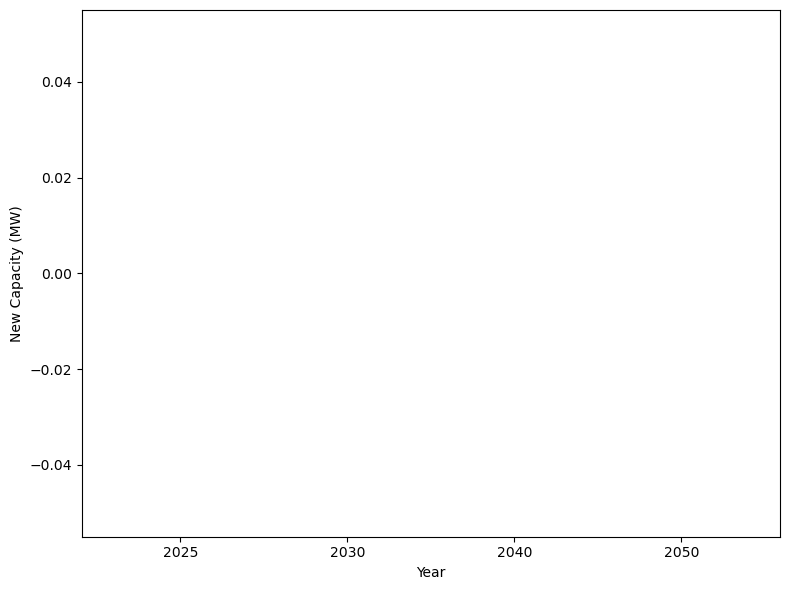

In [ ]:
analytics.plot_branch_new_capacity(branches, savefolder=branches_save_folder)

In [ ]:
branch_buildout_summary = analytics.make_branch_buildout_summary(
    branches, savefolder=branches_save_table_folder
)


branch_buildout_summary

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,5000,0.0,1,0,0.0
2030,5000,0.0,1,0,0.0
2040,5000,0.0,1,0,0.0
2050,5000,0.0,1,0,0.0


In [ ]:
branch_flow_table_per_line = analytics.make_branch_flow_metrics(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_table_per_line

utilization_rate  congestion_rate
line scenario year                                   
35   DE       2040          0.370350         0.029762
              2050          0.399243         0.065476
     GA       2040          0.367230         0.035714
              2050          0.400219         0.065476
     NT       2025          0.303636         0.020833
              2030          0.282220         0.023810
              2040          0.369933         0.035714

In [ ]:
branch_flow_summary = analytics.make_aggregate_branch_flow_summary(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_summary

utilization_rate  congestion_rate
year scenario                                   
2025 NT                0.303636         0.020833
2030 NT                0.282220         0.023810
2040 DE                0.370350         0.029762
     GA                0.367230         0.035714
     NT                0.369933         0.035714
2050 DE                0.399243         0.065476
     GA                0.400219         0.065476

In [ ]:
analytics.plot_new_branches_for_years_with_investments(
    branches, branch_capacity, nodes, savefolder=branches_save_folder
)

## Batteries

In [ ]:
if SAVE_FIGURES:
    batteries_save_folder = os.path.join(figures_folder, "batteries")
    if not os.path.exists(batteries_save_folder):
        os.makedirs(batteries_save_folder)
else:
    batteries_save_folder = None
if SAVE_TABLES:
    batteries_save_table_folder = os.path.join(tables_folder, "batteries")
    if not os.path.exists(batteries_save_table_folder):
        os.makedirs(batteries_save_table_folder)
else:
    batteries_save_table_folder = None

Annual Battery Capacity Investments


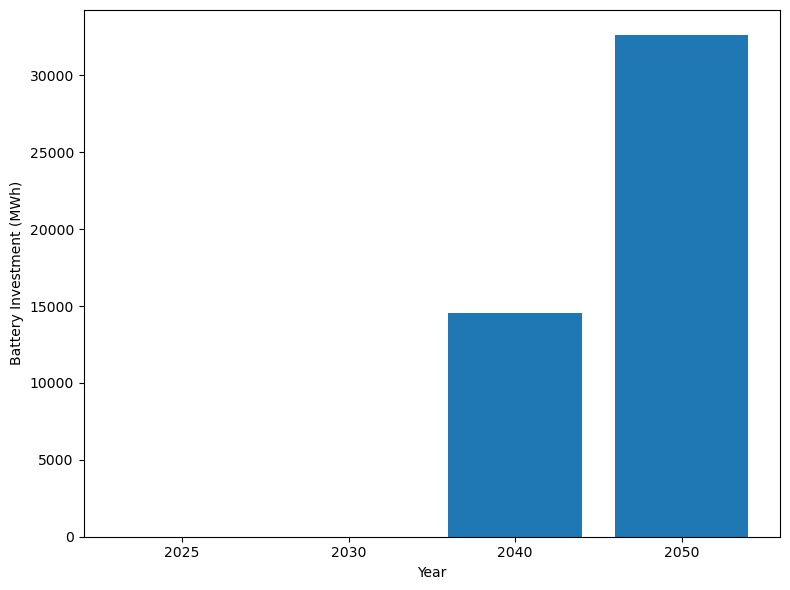

Annual Battery Investment Cost (million €)


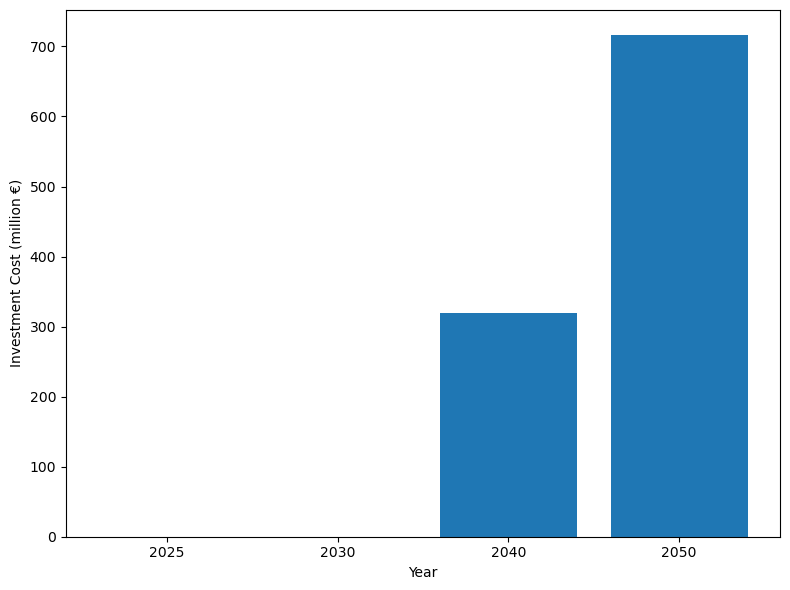

Number of 320 MWh Cycles by Year, Scenario, and Average


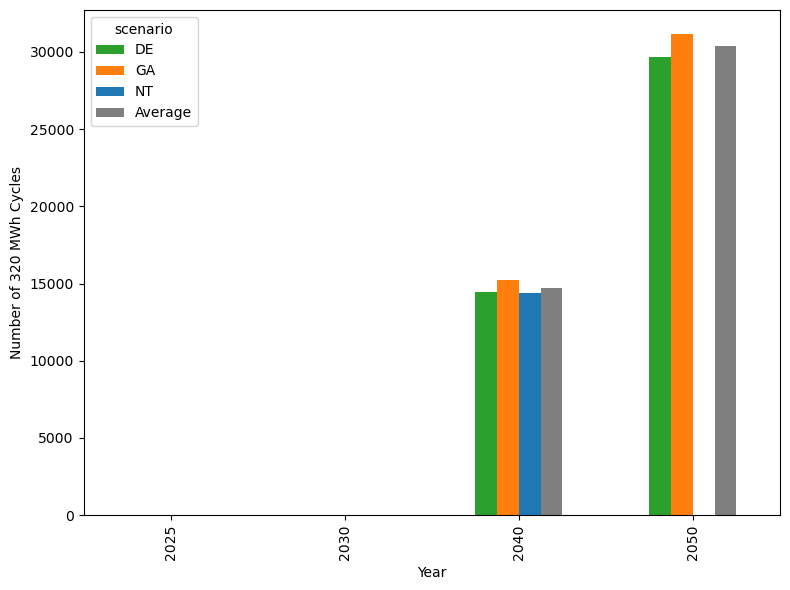

In [ ]:
if len(batteries) > 0:
    batteries = analytics.extend_batteries_table(batteries.copy(), battery_capacity)
    analytics.plot_battery_investment_by_year(
        batteries, savefolder=batteries_save_folder
    )
    analytics.plot_battery_investment_cost_by_year(
        batteries, savefolder=batteries_save_folder
    )
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        batteries_save_table_folder,
    )
    analytics.plot_cycles_per_scenario_with_average(
        battery_discharging,
        week_weights,
        reference_cycle_mwh=400 * (0.8),
        savefolder=batteries_save_folder,
    )
    battery_summary

In [ ]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,0,0.000000,0.000000e+00,NaN
2030,0,0.000000,0.000000e+00,NaN
2040,2,14534.059023,3.191523e+08,323.336937
2050,2,47149.415121,7.161982e+08,206.318908


Annual Curtailment by Year and Scenario


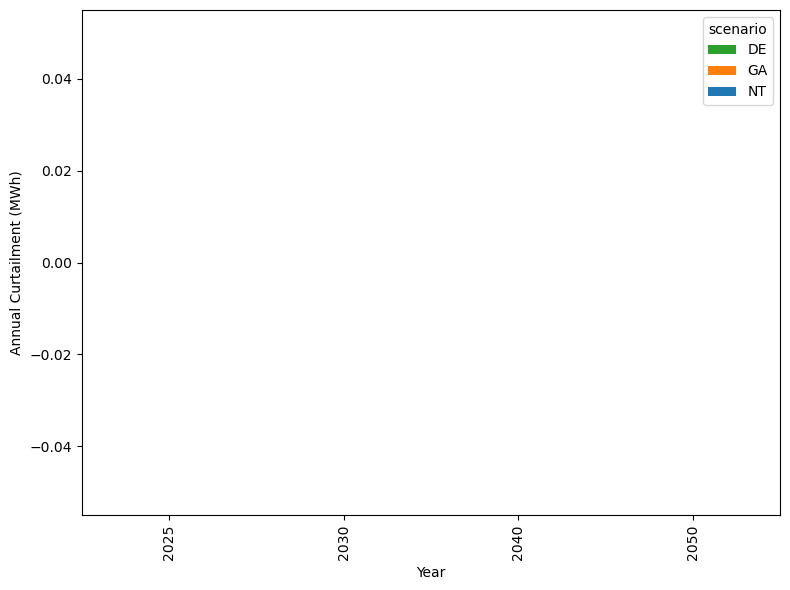

Annual Load Shedding by Year and Scenario


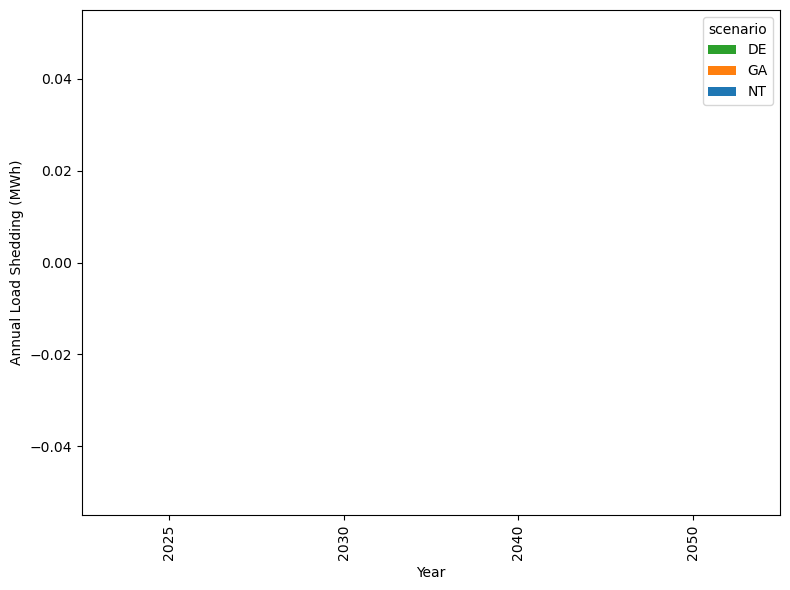

In [ ]:
analytics.plot_curtailment_by_scenario(
    curtailment, week_weights, savefolder=figures_folder
)


analytics.plot_load_shedding_by_scenario(
    load_shedding, week_weights, savefolder=figures_folder
)

In [ ]:
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT                  0.0          0.0                 0.0   
2030 NT                  0.0          0.0                 0.0   
2040 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   
     NT                  0.0          0.0                 0.0   
2050 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

## Macro analysis

In [ ]:
if SAVE_FIGURES:
    macro_save_folder = os.path.join(figures_folder, "macro")
    if not os.path.exists(macro_save_folder):
        os.makedirs(macro_save_folder)
else:
    macro_save_folder = None
if SAVE_TABLES:
    macro_save_table_folder = os.path.join(tables_folder, "macro")
    if not os.path.exists(macro_save_table_folder):
        os.makedirs(macro_save_table_folder)
else:
    macro_save_table_folder = None

In [ ]:
system_summary = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=macro_save_folder,
)

In [ ]:
system_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,192912.81714,121000.945632,11,7,1.252836e+10,2.725703e+08,1.300753e+07,1.040602e+09,2.152064e+09,3.192667e+09,1.572103e+10
2030,192912.81714,37437.358670,11,3,2.060064e+09,2.921416e+08,1.166625e+07,9.333003e+08,1.957952e+09,2.891253e+09,4.951316e+09
2040,192912.81714,23540.312508,11,2,8.380839e+08,3.473449e+08,1.628397e+07,1.302718e+09,2.716440e+09,4.019158e+09,4.857242e+09
2050,192912.81714,0.000000,11,0,0.000000e+00,3.693619e+08,1.832325e+07,1.465860e+09,3.053894e+09,4.519754e+09,4.519754e+09


In [ ]:
if len(batteries) > 0:
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        savefolder=tables_folder,
    )
else:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

In [ ]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,0,0.000000,0.000000e+00,NaN
2030,0,0.000000,0.000000e+00,NaN
2040,2,14534.059023,3.191523e+08,323.336937
2050,2,47149.415121,7.161982e+08,206.318908


In [ ]:
branch_summary = analytics.make_branch_buildout_summary(branches, tables_folder)
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, savefolder=tables_folder
)
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)

Branch buildout summary by year:
Yearly system metrics by year and scenario:


In [ ]:
branch_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,5000,0.0,1,0,0.0
2030,5000,0.0,1,0,0.0
2040,5000,0.0,1,0,0.0
2050,5000,0.0,1,0,0.0


In [ ]:
yearly_system_cost_table

production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.725703e+08  1.300753e+07       1.040602e+09     2.152064e+09   
2030 NT        2.921416e+08  1.166625e+07       9.333003e+08     1.957952e+09   
2040 DE        3.632854e+08  1.846069e+07       1.476855e+09     3.058474e+09   
     GA        3.238910e+08  1.314106e+07       1.051285e+09     2.218599e+09   
     NT        3.548582e+08  1.725016e+07       1.380013e+09     2.872248e+09   
2050 DE        3.911035e+08  2.161876e+07       1.729501e+09     3.566437e+09   
     GA        3.476203e+08  1.502774e+07       1.202219e+09     2.541351e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         3.192667e+09  
2030 NT                         2.891253e+09  
2040 DE                         4.535329e+09  
     GA                         3.269883e+09  
     NT                         4.252261e+09  
2050 DE                         5.295937e+09  
     GA                         3.743571e+09

In [ ]:
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT                  0.0          0.0                 0.0   
2030 NT                  0.0          0.0                 0.0   
2040 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   
     NT                  0.0          0.0                 0.0   
2050 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

Annual System Costs (average across scenarios)


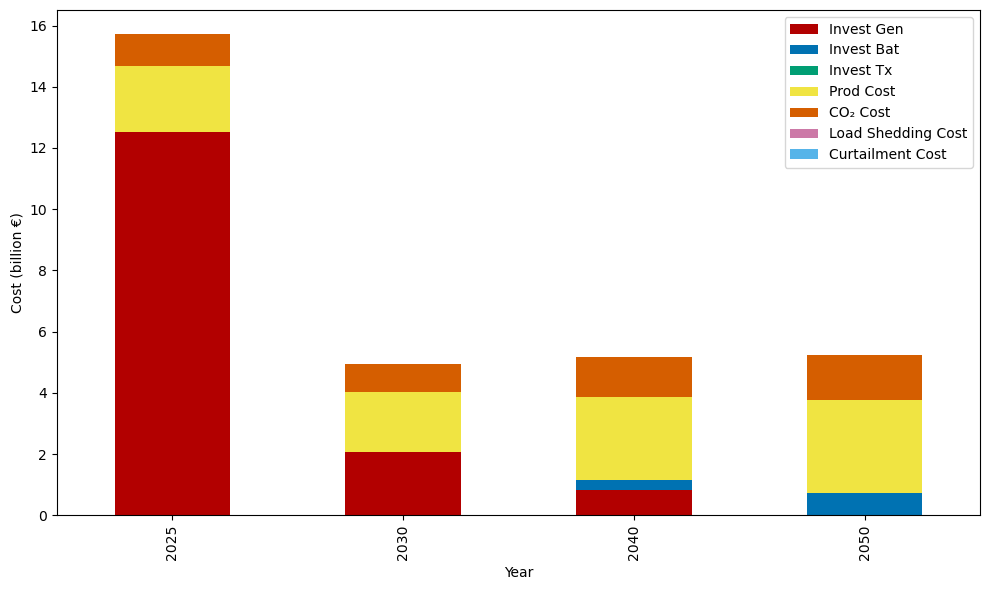

Annual System Costs by Scenario


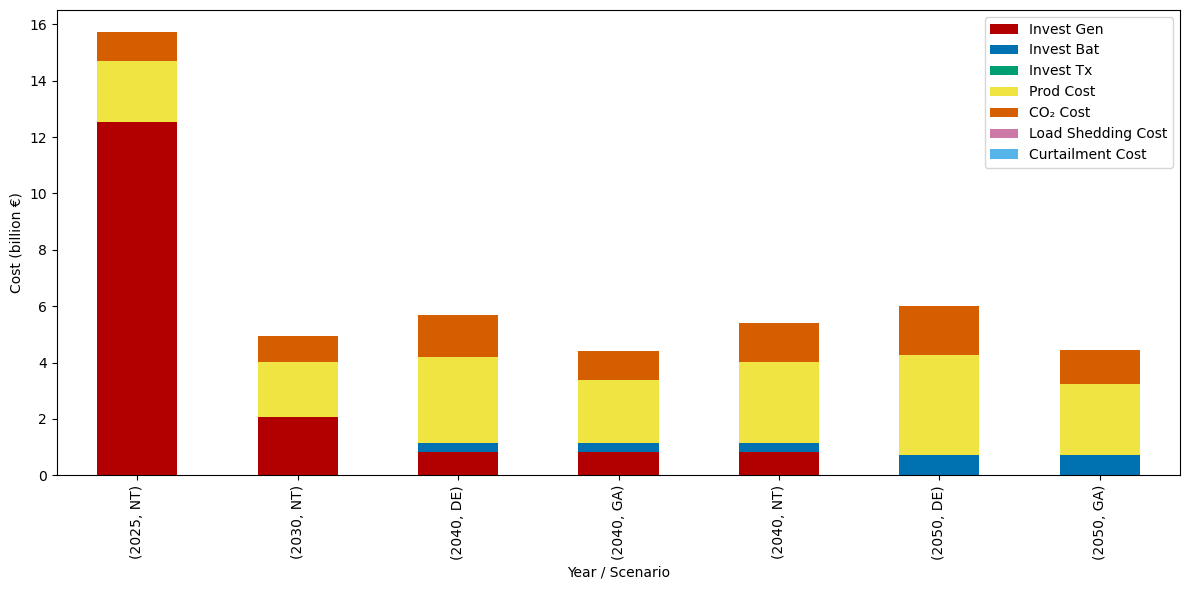

In [ ]:
analytics.plot_yearly_costs_stacked_avg(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)
analytics.plot_yearly_costs_stacked_by_scenario(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)

In [ ]:
total_system_cost = analytics.compute_total_system_cost(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
total_system_cost

Total system cost by year:


,AIC,expected_OC,total_cost
year,,,
2025,1.252836e+10,3.192667e+09,1.572103e+10
2030,2.060064e+09,2.891253e+09,4.951316e+09
2040,1.157236e+09,4.019158e+09,5.176394e+09
2050,7.161982e+08,4.519754e+09,5.235952e+09


In [ ]:
assert (
    abs(total_system_cost["total_cost"].sum() - model_info["Objective Value"][0]) < 1000
), f"Mismatch in total system cost: {total_system_cost['total_cost'].sum():,.0f} vs {model_info['Objective Value'][0]:,.0f}"

In [ ]:
mega_table = analytics.make_mega_cost_table(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
mega_table

Invest Gen    Invest Bat  Invest Tx  Production Cost  \
year scenario                                                           
2025 NT        1.252836e+10  0.000000e+00        0.0     2.152064e+09   
2030 NT        2.060064e+09  0.000000e+00        0.0     1.957952e+09   
2040 DE        8.380839e+08  3.191523e+08        0.0     3.058474e+09   
     GA        8.380839e+08  3.191523e+08        0.0     2.218599e+09   
     NT        8.380839e+08  3.191523e+08        0.0     2.872248e+09   
2050 DE        0.000000e+00  7.161982e+08        0.0     3.566437e+09   
     GA        0.000000e+00  7.161982e+08        0.0     2.541351e+09   
All  All       1.542651e+10  1.035350e+09        0.0     9.880351e+09   

               CO2 Emission Cost  Load Shedding Cost  Curtailment Cost  \
year scenario                                                            
2025 NT             1.040602e+09                 0.0               0.0   
2030 NT             9.333003e+08                 0.0               0.0   
2040 DE             1.476855e+09                 0.0               0.0   
     GA             1.051285e+09                 0.0               0.0   
     NT             1.380013e+09                 0.0               0.0   
2050 DE             1.729501e+09                 0.0               0.0   
     GA             1.202219e+09                 0.0               0.0   
All  All            4.742480e+09                 0.0               0.0   

               Prod+CO2 Cost   Total CapEx    Total OpEx    Total Cost  
year scenario                                                           
2025 NT         3.192667e+09  1.252836e+10  3.192667e+09  1.572103e+10  
2030 NT         2.891253e+09  2.060064e+09  2.891253e+09  4.951316e+09  
2040 DE         4.535329e+09  1.157236e+09  4.535329e+09  5.692565e+09  
     GA         3.269883e+09  1.157236e+09  3.269883e+09  4.427119e+09  
     NT         4.252261e+09  1.157236e+09  4.252261e+09  5.409497e+09  
2050 DE         5.295937e+09  7.161982e+08  5.295937e+09  6.012135e+09  
     GA         3.743571e+09  7.161982e+08  3.743571e+09  4.459769e+09  
All  All        1.462283e+10  1.646186e+10  1.462283e+10  3.108469e+10

In [ ]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,52610.664000,26305.332000
2030,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,105221.328000,26305.332000
2040,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,157831.992000,26305.332000
2050,ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,52610.664000,0.000000,0.000000,210442.656000,26305.332000
2025,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,9478.786965,4739.393483
2030,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,18957.573931,4739.393483
2040,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,28436.360896,4739.393483
2050,ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal,True,9478.786965,0.000000,0.000000,37915.147862,4739.393483
2025,ES1 0 offwind-ac,ES1 0,offwind-ac,9274.463486,0.015000,184160.119456,0.00,#6895dd,Offshore Wind (AC),True,18548.926971,18548.926971,18548.926971,18548.926971,27823.390457


In [ ]:
# End  by saving the extended generators, transmission lines, and batteries tables to and extended tables folder
if tables_folder:
    # Create the extended tables folder if it doesn't exist
    extended_tables_folder = os.path.join(tables_folder, "extended_tables")
    os.makedirs(extended_tables_folder, exist_ok=True)
    generators.to_csv(
        os.path.join(extended_tables_folder, "extended_generators.csv"), index=True
    )
    branches.to_csv(
        os.path.join(extended_tables_folder, "extended_branches.csv"), index=True
    )
    batteries.to_csv(
        os.path.join(extended_tables_folder, "extended_batteries.csv"), index=True
    )

# Dual Variables Analysis

In [ ]:
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))
    print("------------------------")

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 21   0            0.0
                             1            0.0

------------------------
battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


------------------------
battery_discharge_new_max_duals



...

------------------------
load_shedding_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 21   0            0.0
                         1            0.0

------------------------
power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 21   0       56.77238
                         1       56.77238

------------------------


In [ ]:
# Build a DataFrame of scenario probabilities (p_{ω,y})
prob_rows = []
for year_str, scen_list in scenarios.items():
    year = int(year_str)
    probs = scenario_probabilities[year_str]
    for scen, p in zip(scen_list, probs):
        prob_rows.append({"year": year, "scenario": scen, "p": p})
prob_df = pd.DataFrame(prob_rows).set_index(["year", "scenario"])

prob_df

p
year scenario          
2025 NT        1.000000
2030 NT        1.000000
2040 NT        0.333333
     GA        0.333333
     DE        0.333333
2050 GA        0.500000
     DE        0.500000

In [ ]:
# Loop through duals and apply 1/p weighting where appropriate
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))

    # Only apply to duals that vary by scenario
    if "scenario" in df.index.names:
        temp = df.reset_index().merge(prob_df, on=["year", "scenario"], how="left")
        # Compute 1/p weight
        temp["weight"] = 1.0 / temp["p"]
        # Apply weight to the dual values
        temp["dual_value"] = temp["dual_value"] * temp["weight"]

        # Reconstruct a weighted-dual Series with the original index
        weighted = temp.set_index(df.index.names)
        # Display the first two rows
        display(weighted.head(2))
        dual_variables[key] = weighted

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 21   0            0.0
                             1            0.0

dual_value    p  weight
battery   scenario year week hour                         
ES1 0 bat NT       2025 21   0            0.0  1.0     1.0
                             1            0.0  1.0     1.0

battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


...

dual_value
node  scenario year week hour            
ES1 0 NT       2025 21   0            0.0
                         1            0.0

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 21   0            0.0  1.0     1.0
                         1            0.0  1.0     1.0

power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 21   0       56.77238
                         1       56.77238

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 21   0       56.77238  1.0     1.0
                         1       56.77238  1.0     1.0

In [ ]:
# dual variables
battery_charge_new_max_duals = dual_variables["battery_charge_new_max_duals"]
battery_charge_old_duals = dual_variables["battery_charge_old_duals"]
battery_discharge_new_max_duals = dual_variables["battery_discharge_new_max_duals"]
battery_discharge_old_duals = dual_variables["battery_discharge_old_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
branch_flow_old_duals_min = dual_variables["branch_flow_old_duals_min"]
branch_flow_old_duals_max = dual_variables["branch_flow_old_duals_max"]
branch_flow_new_duals_min = dual_variables["branch_flow_new_duals_min"]
branch_flow_new_duals_max = dual_variables["branch_flow_new_duals_max"]
emissions_duals = dual_variables["emissions_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

### Power Balance Duals

In [ ]:
node_to_city = {
    "ES1 0": "Murcia",
    "ES1 1": "Bilbao",
    "ES1 2": "Zaragoza",
    "ES1 3": "Seville",
    "ES1 4": "Lugo",
    "ES1 5": "Madrid",
    "ES1 6": "Valencia",
    "ES1 7": "Salamanca",
    "ES1 8": "Barcelona",
    "PT1 0": "Porto",
    "PT1 1": "Lisbon",
}

In [ ]:
if SAVE_FIGURES:
    # Create the figures folder if it doesn't exist
    dual_folder = os.path.join(RESULTS_FOLDER, "duals")
    os.makedirs(dual_folder, exist_ok=True)
else:
    dual_folder = None
if SAVE_TABLES:
    # Create the tables folder if it doesn't exist
    dual_tables_folder = os.path.join(tables_folder, "duals")
    os.makedirs(dual_tables_folder, exist_ok=True)
else:
    dual_tables_folder = None

In [ ]:
lmp_table = analytics.make_nodal_price_table(
    power_balance_duals, savefolder=dual_tables_folder
)

lmp_table

Annual Average Locational Marginal Prices by Node


node               ES1 0      PT1 0
year scenario                      
2025 NT        34.581998  35.250656
2030 NT        30.298400  30.893641
2040 DE        40.964221  41.751898
     GA        30.547636  31.128087
     NT        34.025550  34.679067
2050 DE        50.744045  51.699856
     GA        33.114486  33.593931

In [ ]:
annual_lmp_table = analytics.make_annual_lmp_table(
    power_balance_duals, savefolder=dual_tables_folder
)
annual_lmp_table

scenario,DE,GA,NT,Average
year,,,,
2025,NaN,NaN,34.916327,34.916327
2030,NaN,NaN,30.596020,30.596020
2040,41.35806,30.837862,34.352308,35.516077
2050,51.22195,33.354209,NaN,42.288080


Average LMP by Year and Scenario (±1 std)


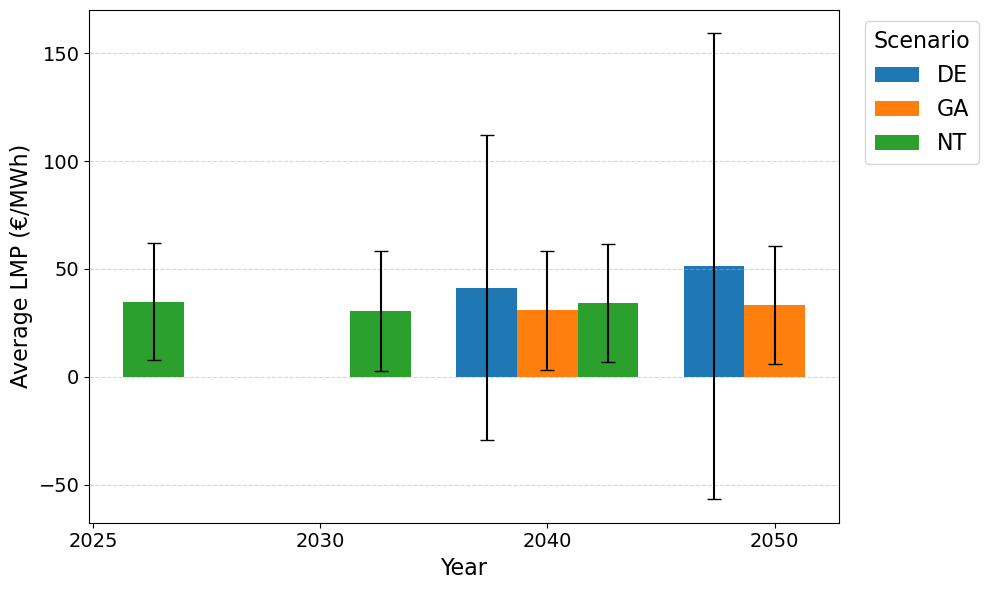

In [ ]:
analytics.plot_annual_lmp_by_scenario(power_balance_duals, savefolder=dual_folder)

Average LMP by Year and Scenario


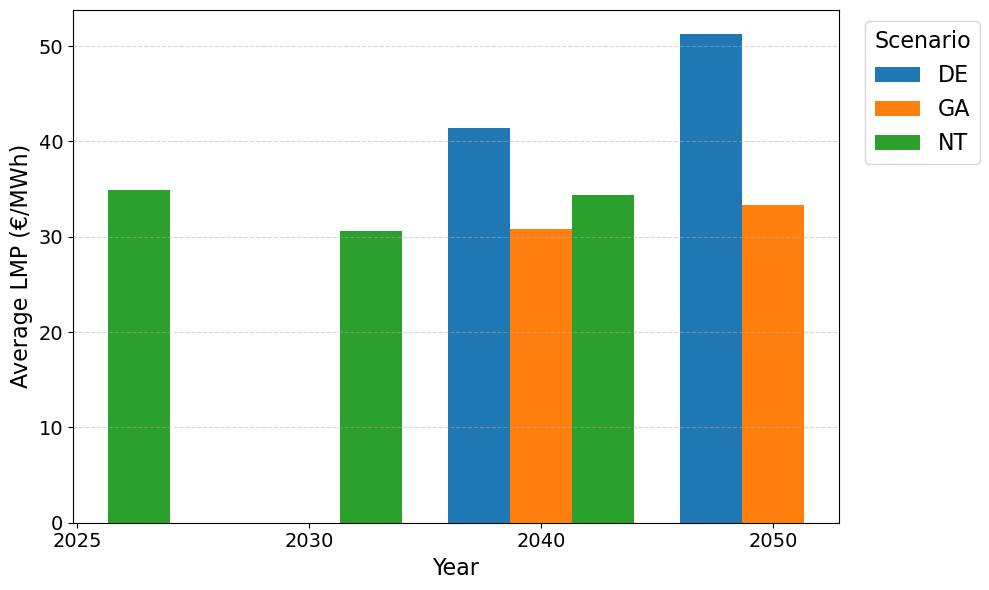

In [ ]:
analytics.plot_annual_lmp_by_scenario_simple(
    power_balance_duals, savefolder=dual_folder
)

Average LMP by Year and Scenario (line chart)


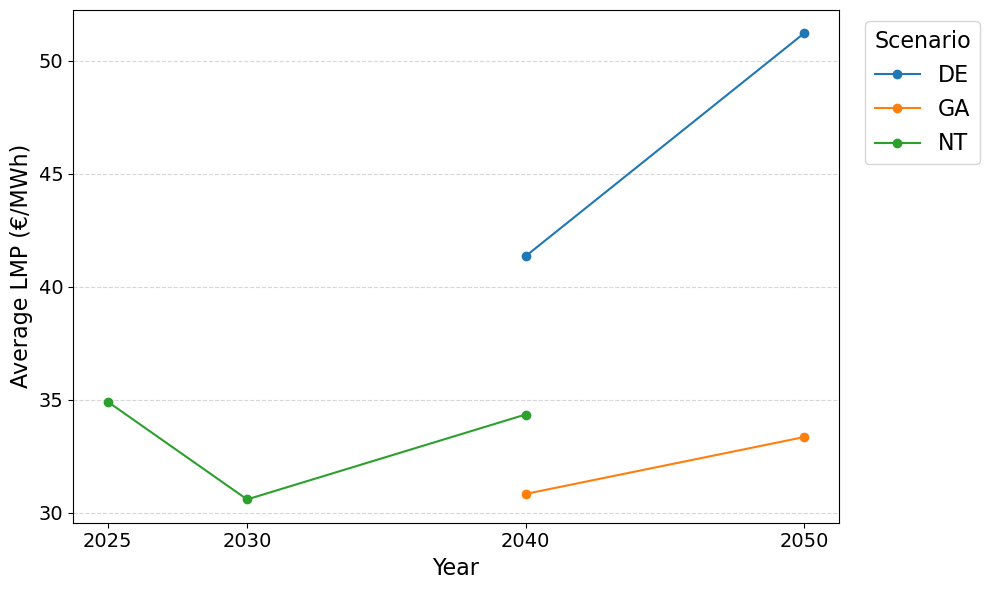

In [ ]:
analytics.plot_annual_lmp_by_scenario_line(power_balance_duals, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (with markers)


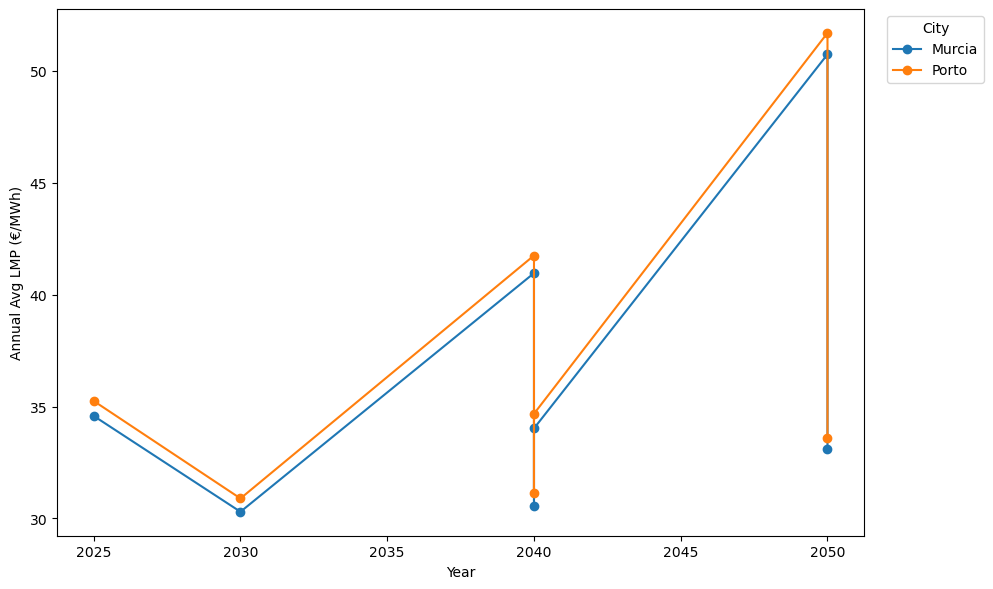

In [ ]:
analytics.plot_nodal_price_evolution_with_markers(lmp_table, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (grouped bar)


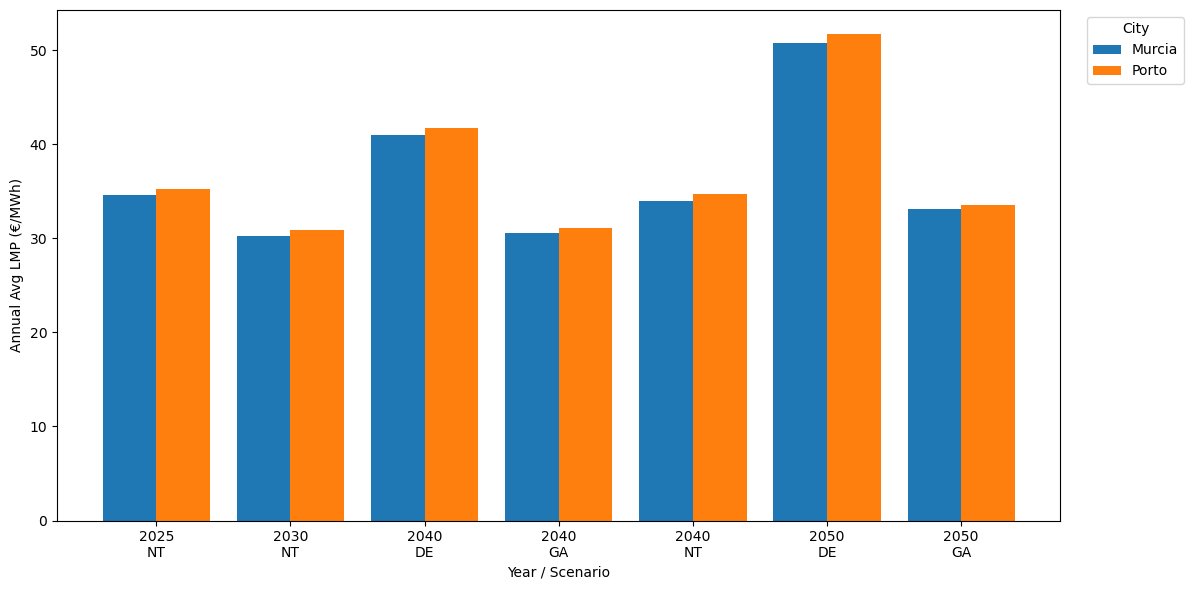

In [ ]:
analytics.plot_nodal_price_grouped_bar(
    lmp_table, node_to_city=node_to_city, savefolder=dual_folder
)

In [ ]:
branch_extension_duals = branch_extension_duals.rename_axis(index={"branch": "line"})
branch_extension_duals

dual_value
line year            
35   2025         0.0
     2030         0.0
     2040         0.0
     2050         0.0

In [ ]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators.groupby("carrier")["production_cost"].mean().sort_values(ascending=True)

carrier
ror            0.000000
solar          0.010000
offwind-ac     0.015000
onwind         0.015000
coal          55.396970
CCGT          55.824539
Name: production_cost, dtype: float64

In [ ]:
freqs = analytics.compute_lmp_bucket_frequencies(
    power_balance_duals, generators, dual_tables_folder
)


freqs

LMP Bucket Frequencies


,lower,upper,absolute,relative_percent
bucket,,,,
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000
solar,0.009000,0.011000,470,9.991497
gap_solar_wind,0.011000,0.013500,0,0.000000
wind,0.013500,0.016500,1336,28.401361
gap_wind_thermal,0.016500,49.857273,35,0.744048
thermal,49.857273,61.406993,2839,60.352891
other,NaN,NaN,24,0.510204


LMP Bucket Absolute Frequencies


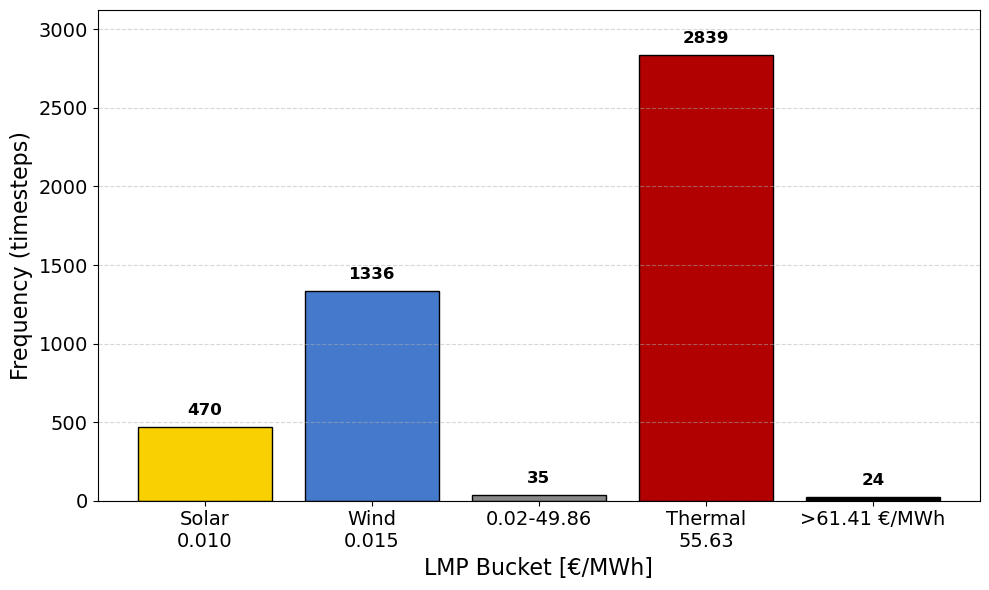

In [ ]:
analytics.plot_lmp_bucket_frequencies(freqs, savefolder=dual_folder)

In [ ]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000
solar,0.009000,0.011000,470,9.991497
gap_solar_wind,0.011000,0.013500,0,0.000000
wind,0.013500,0.016500,1336,28.401361
gap_wind_thermal,0.016500,49.857273,35,0.744048
thermal,49.857273,61.406993,2839,60.352891
other,NaN,NaN,24,0.510204


LMP Bucket Relative Frequencies (%)


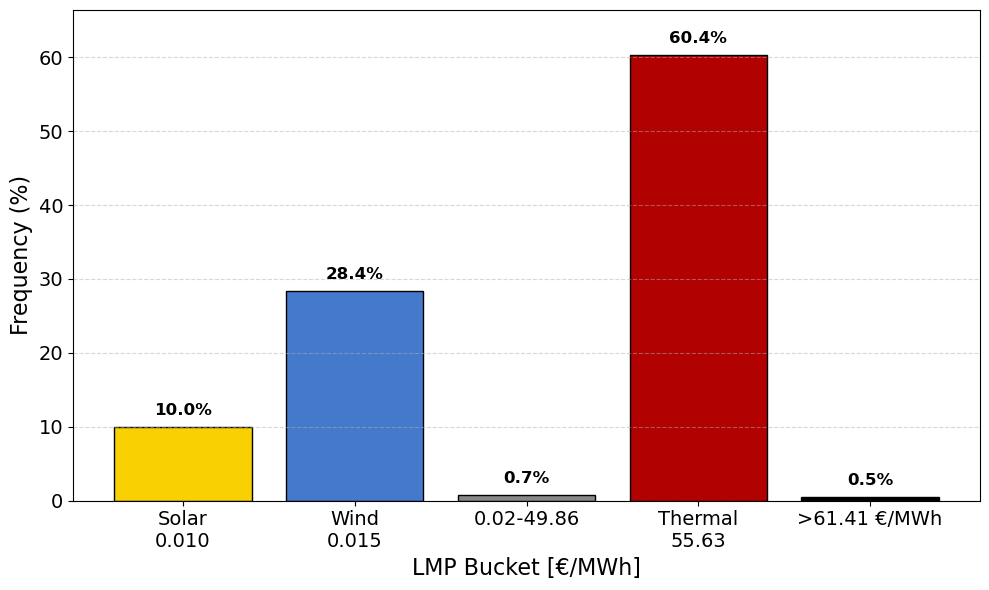

In [ ]:
analytics.plot_lmp_bucket_percentages(freqs, savefolder=dual_folder)

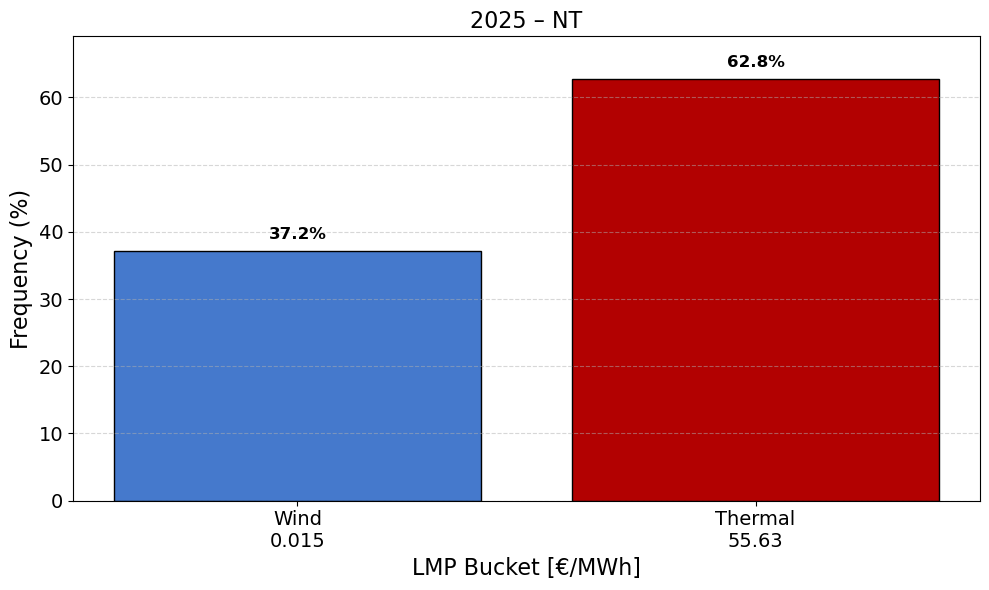

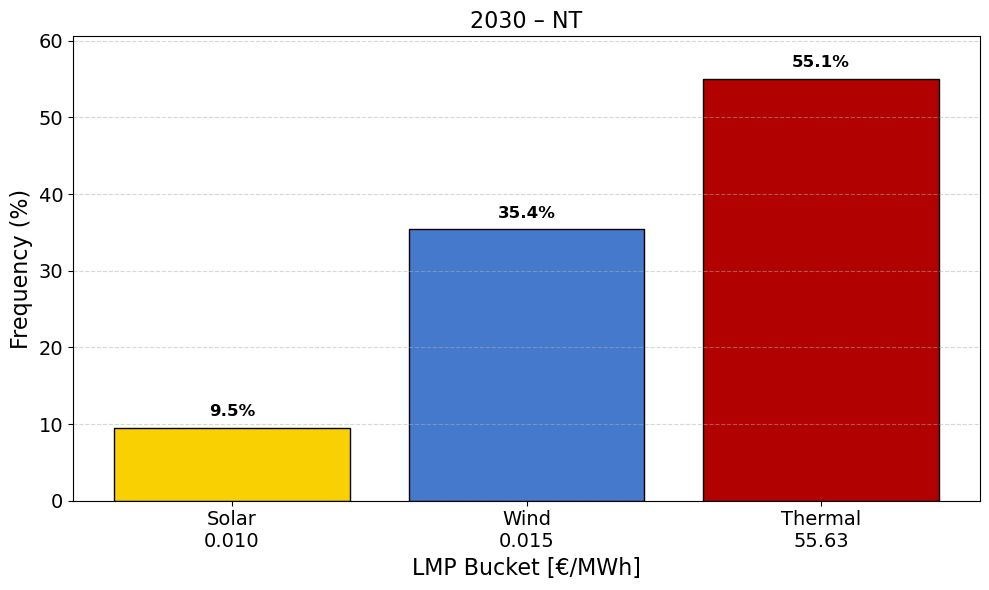

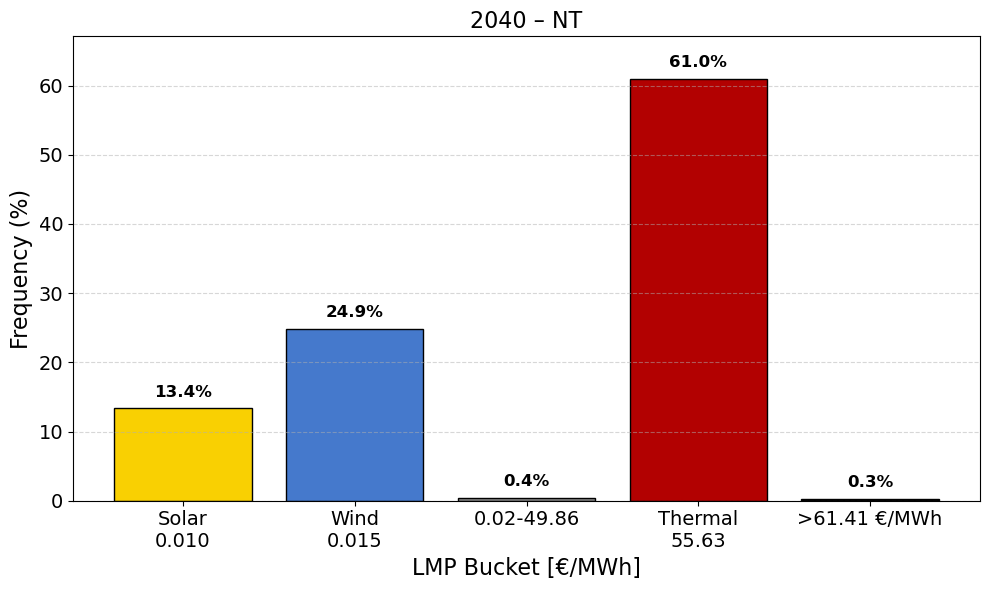

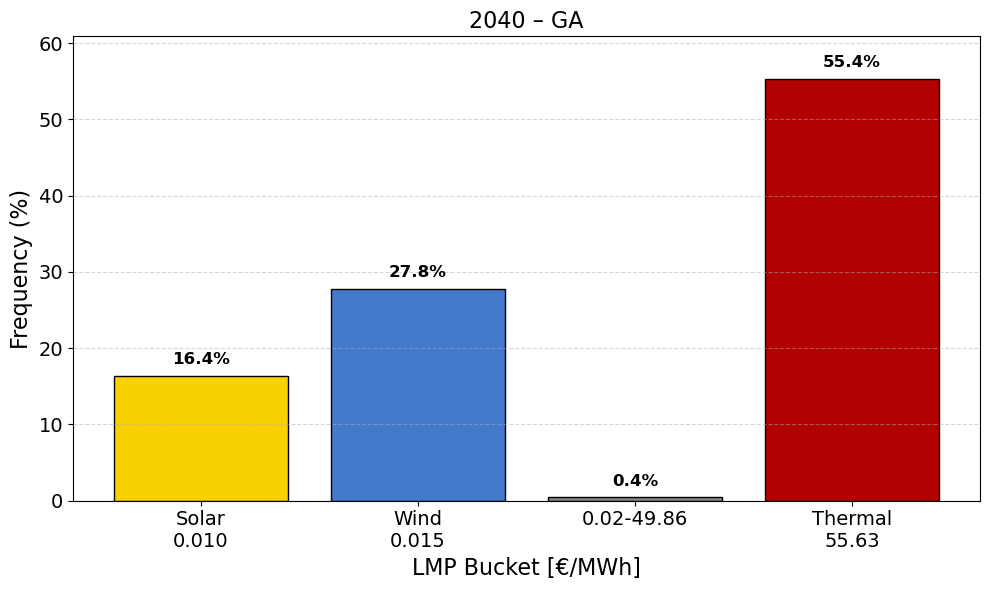

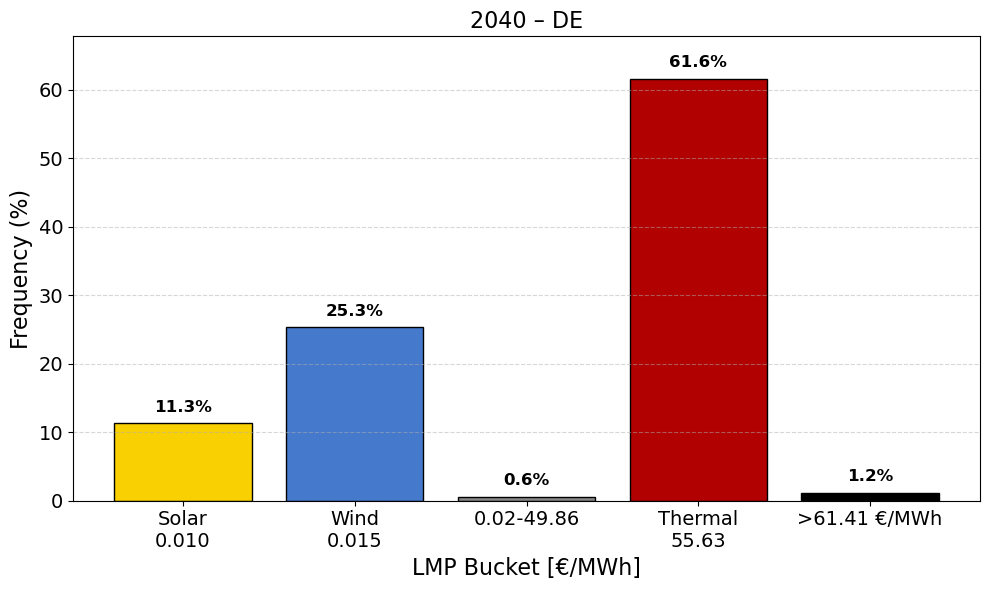

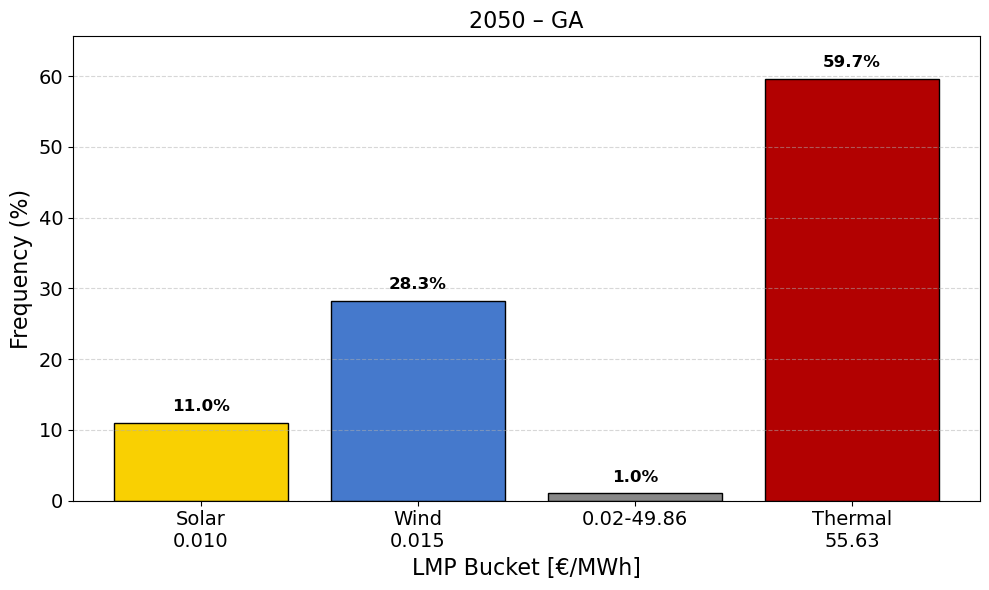

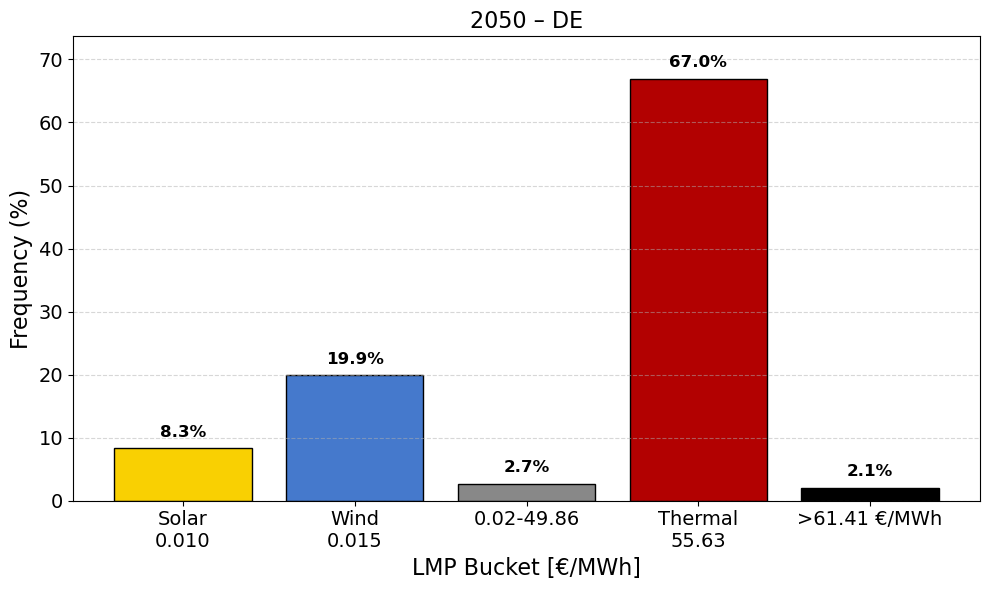

In [ ]:
analytics.plot_lmp_bucket_percentages_by_year_scenario(
    power_balance_duals, freqs, savefolder=dual_folder
)

LMP event counts above 61.41 €/MWh by Year & Scenario


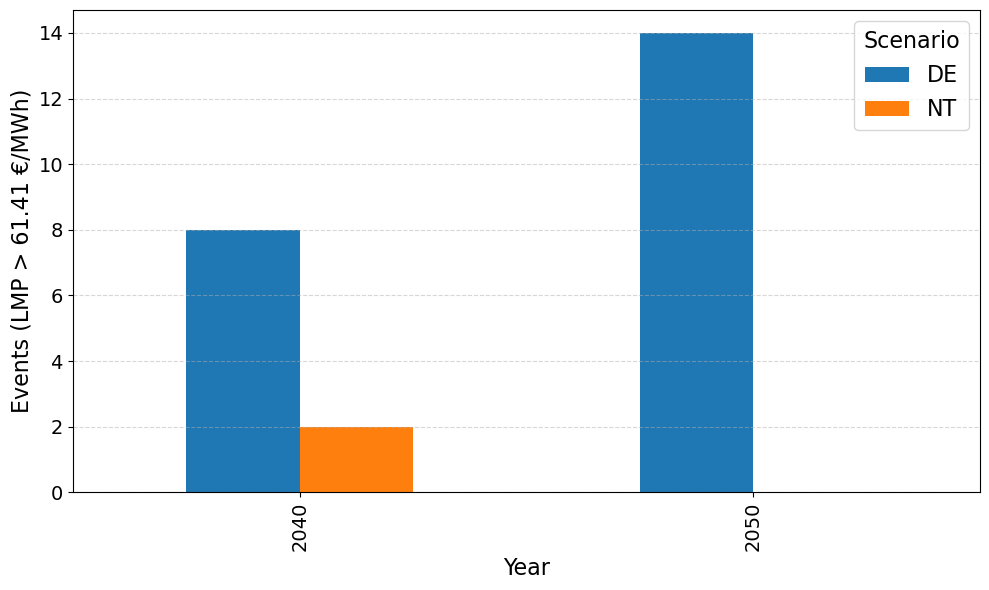

In [ ]:
# determine cap from your buckets:
cap = freqs.loc[freqs.index != "other", "upper"].max()

analytics.plot_high_lmp_event_counts(power_balance_duals, cap, savefolder=dual_folder)

61.406992782923496
Distribution of LMPs > 61.41 €/MWh


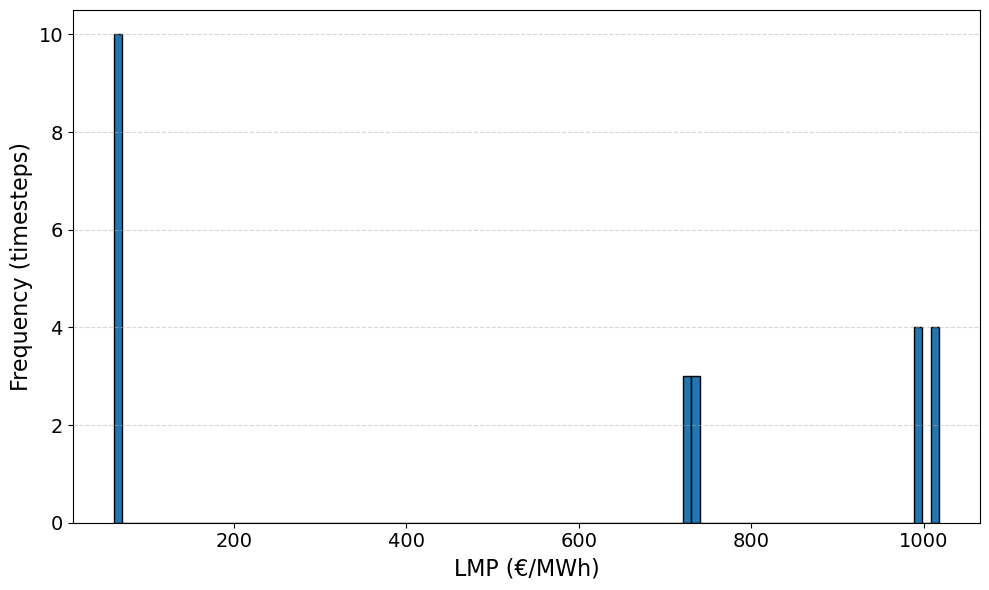

In [ ]:
cap = freqs.loc[freqs.index != "other", "upper"].max()
print(cap)


analytics.plot_high_lmp_distribution(
    power_balance_duals, cap, n_bins=100, savefolder=dual_folder
)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
49     1007.188     1017.539      4        28.571429          0.085034
48      996.838     1007.188      4        28.571429          0.085034
22      727.717      738.068      3        21.428571          0.063776
21      717.366      727.717      3        21.428571          0.063776
36      872.628      882.979      0         0.000000          0.000000
28      789.822      800.173      0         0.000000          0.000000
29      800.173      810.524      0         0.000000          0.000000
30      810.524      820.874      0         0.000000          0.000000
31      820.874      831.225      0         0.000000          0.000000
32      831.225      841.576      0         0.000000          0.000000
Top 5 high-LMP bins by occurrence


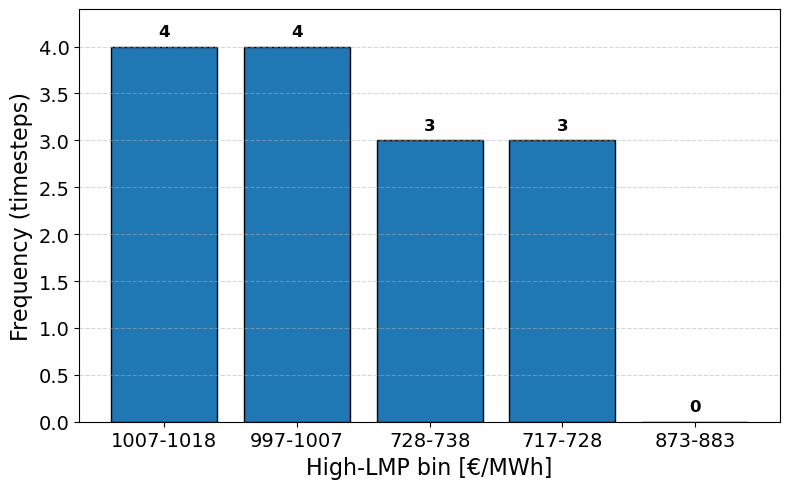

In [ ]:
high_tbl = analytics.make_high_lmp_frequency_table(
    power_balance_duals, cap=500, n_bins=50, savefolder=dual_tables_folder
)
top5 = analytics.get_top_high_lmp_buckets(
    high_tbl, top_n=10, savefolder=dual_tables_folder
)
print(top5)
analytics.plot_top_high_lmp_buckets(high_tbl, top_n=5, savefolder=dual_folder)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
0        61.406       70.968     10        41.666667          0.212585
97      988.855      998.417      4        16.666667          0.085034
99     1007.978     1017.539      4        16.666667          0.085034
70      730.700      740.261      3        12.500000          0.063776
69      721.138      730.700      3        12.500000          0.063776
3        90.091       99.652      0         0.000000          0.000000
52      558.596      568.157      0         0.000000          0.000000
74      768.945      778.506      0         0.000000          0.000000
73      759.384      768.945      0         0.000000          0.000000
72      749.822      759.384      0         0.000000          0.000000
Top 6 high-LMP bins by occurrence


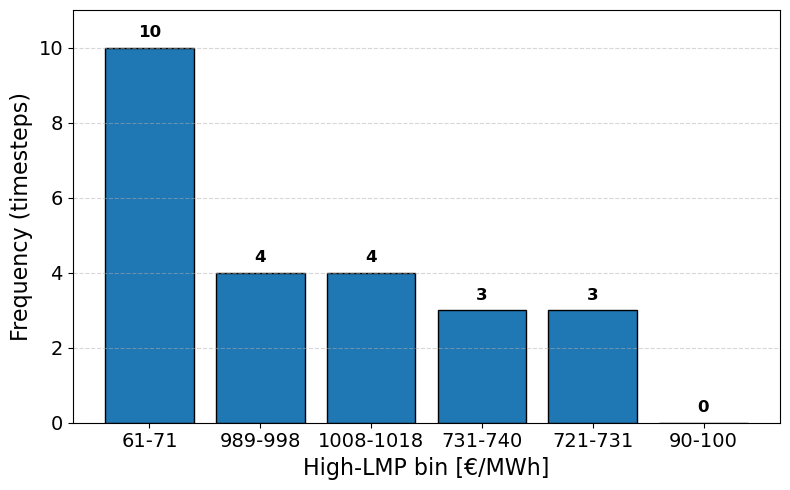

In [ ]:
high_tbl = analytics.make_high_lmp_frequency_table(
    power_balance_duals, cap=cap, n_bins=100, savefolder=dual_tables_folder
)
top5 = analytics.get_top_high_lmp_buckets(
    high_tbl, top_n=10, savefolder=dual_tables_folder
)
print(top5)
analytics.plot_top_high_lmp_buckets(high_tbl, top_n=6, savefolder=dual_folder)

Detailed histogram for top high-LMP bucket (61.41–70.97 €/MWh)


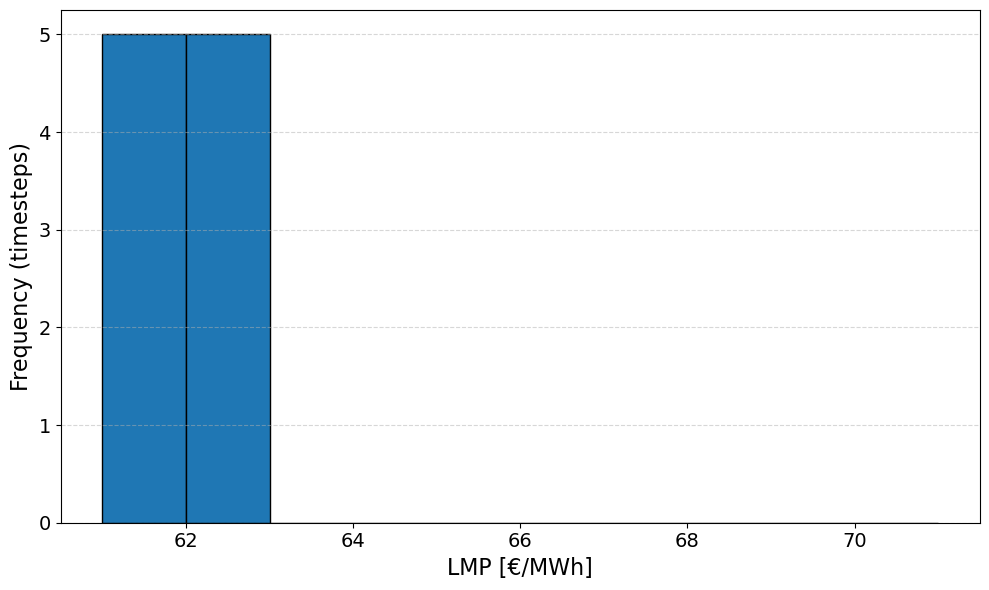

In [ ]:
# Assuming you've already built `high_tbl`:
analytics.plot_top_high_bucket_detail(
    power_balance_duals, high_tbl, width=1.0, savefolder=dual_folder
)

In [ ]:
power_balance_duals

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 21   0       56.77238  1.0     1.0
                         1       56.77238  1.0     1.0
                         2       56.77238  1.0     1.0
                         3       56.77238  1.0     1.0
                         4       56.77238  1.0     1.0
...                                   ...  ...     ...
PT1 0 DE       2050 42   163     57.93100  0.5     2.0
                         164     57.93100  0.5     2.0
                         165     57.93100  0.5     2.0
                         166     56.52752  0.5     2.0
                         167     56.52752  0.5     2.0

[4704 rows x 3 columns]

               count_total  count_bucket  percent_bucket_of_total
year scenario                                                    
2025 NT                672             0                 0.000000
2030 NT                672             0                 0.000000
2040 DE                672             4                 0.595238
     GA                672             3                 0.446429
     NT                672             3                 0.446429
2050 DE                672            18                 2.678571
     GA                672             7                 1.041667
Distribution of LMPs in bucket 'gap_wind_thermal'


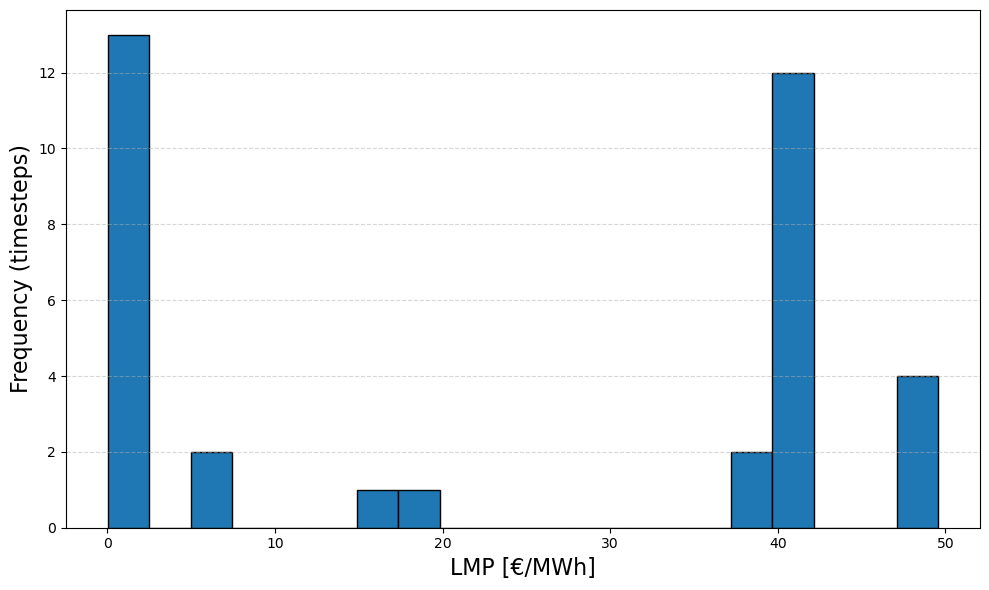

In [ ]:
gap_subset = analytics.extract_duals_in_lmp_bucket(
    power_balance_duals, freqs, "gap_wind_thermal"
)
gap_summary = analytics.summarize_gap_duals_by_year_scenario(
    gap_subset, power_balance_duals, savefolder=dual_tables_folder
)
print(gap_summary)
analytics.plot_gap_lmp_distribution(
    gap_subset, "gap_wind_thermal", savefolder=dual_folder
)

LMP ≥ 70 €/MWh: count = 14 timesteps


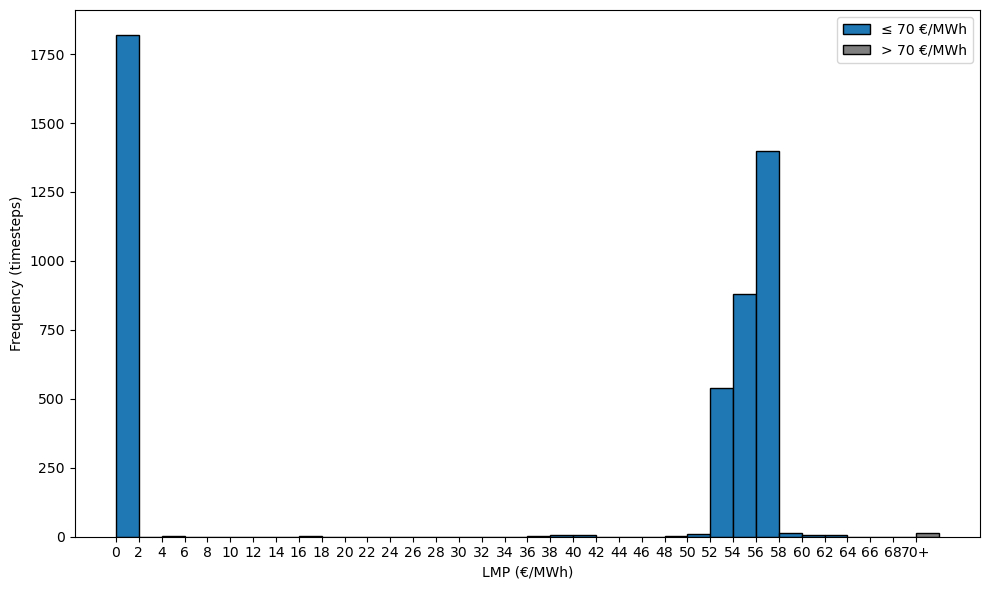

In [ ]:
analytics.plot_lmp_histogram_70plus(
    power_balance_duals, cap=70, bin_width=2.0, savefolder=dual_folder
)

In [ ]:
freq_table = analytics.make_lmp_frequency_table(
    power_balance_duals, bin_width=1.0, cap=70, savefolder=dual_tables_folder
)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    sorted_freq_table = freq_table.sort_values(by="count", ascending=False)
    display(sorted_freq_table)

,lower_bound,upper_bound,count,percent,count_2025,count_2030,count_2040,count_2050
0,0.0,1.0,1819,38.669218,250,302,808,459
56,56.0,57.0,846,17.984694,103,87,382,274
54,54.0,55.0,562,11.947279,111,100,211,140
57,57.0,58.0,551,11.713435,70,61,237,183
53,53.0,54.0,524,11.139456,106,97,190,131
55,55.0,56.0,319,6.781463,32,25,163,99
52,52.0,53.0,16,0.340136,0,0,8,8
70,70.0,inf,14,0.297619,0,0,6,8
39,39.0,40.0,6,0.127551,0,0,0,6
40,40.0,41.0,6,0.127551,0,0,0,6


In [ ]:
generators["production_cost"].groupby(generators["carrier"]).mean().sort_values(
    ascending=True
)

carrier
ror            0.000000
solar          0.010000
offwind-ac     0.015000
onwind         0.015000
coal          55.396970
CCGT          55.824539
Name: production_cost, dtype: float64

In [ ]:
# plot_top_10_dual_intervals(
#     power_balance_duals, sorted_freq_table, n_bins=10, savefolder=dual_folder
# )
# create_top_10_dual_intervals_tables(
#     power_balance_duals, freq_table, n_bins=10, savefolder=dual_tables_folder
# )

In [ ]:
average_duals = power_balance_duals.groupby("year")["dual_value"].mean()
average_duals

year
2025    34.916327
2030    30.596020
2040    35.516077
2050    42.288080
Name: dual_value, dtype: float64

In [ ]:
summary_by_carrier = analytics.summarise_extension_status_by_carrier(
    generators, savefolder=generators_save_table_folder
)


summary_by_carrier

Extension status by carrier


extension_status  not extended  partly extended  fully extended
year carrier                                                   
2025 CCGT                    1                1               0
     coal                    1                0               0
     offwind-ac              0                0               2
     onwind                  0                0               2
     ror                     2                0               0
     solar                   0                0               2
2030 CCGT                    2                0               0
     coal                    1                0               0
     offwind-ac              2                0               0
     onwind                  1                1               0
     ror                     2                0               0
     solar                   0                0               2
2040 CCGT                    2                0               0
     coal                    1                0               0
     offwind-ac              2                0               0
     onwind                  2                0               0
     ror                     2                0               0
     solar                   0                2               0
2050 CCGT                    2                0               0
     coal                    1                0               0
     offwind-ac              2                0               0
     onwind                  2                0               0
     ror                     2                0               0
     solar                   2                0               0

In [ ]:
# Usage example:
summary_table = analytics.summarize_dual_nonzero_counts(
    dual_variables, dual_tables_folder
)
summary_table

,total_duals,nonzero_duals,percent_nonzero
dual,,,
battery_charge_new_max_duals,4704,90,1.913265
battery_charge_old_duals,0,0,0.000000
battery_discharge_new_max_duals,4704,66,1.403061
battery_discharge_old_duals,0,0,0.000000
branch_extension_duals,4,0,0.000000
branch_flow_new_duals_max,2352,3,0.127551
branch_flow_new_duals_min,2352,63,2.678571
branch_flow_old_duals_max,2352,0,0.000000
branch_flow_old_duals_min,2352,60,2.551020


In [ ]:
summary = analytics.summarize_duals_by_year_scenario(
    dual_variables, savefolder=dual_tables_folder
)

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):

    display(summary)

total_duals  nonzero_duals  \
dual                            year scenario                               
battery_charge_new_max_duals    2025 NT                672             12   
                                2030 NT                672             32   
                                2040 DE                672             12   
                                     GA                672             18   
                                     NT                672             16   
                                2050 DE                672              0   
                                     GA                672              0   
battery_discharge_new_max_duals 2025 NT                672             20   
                                2030 NT                672              7   
                                2040 DE                672             10   
                                     GA                672             10   
                                     NT                672             10   
                                2050 DE                672              4   
                                     GA                672              5   
branch_extension_duals          2025 All                 1              0   
                                2030 All                 1              0   
                                2040 All                 1              0   
                                2050 All                 1              0   
branch_flow_new_duals_max       2025 NT                336              0   
                                2030 NT                336              1   
                                2040 DE                336              0   
                                     GA                336              0   
                                     NT                336              0   
                                2050 DE                336              2   
                                     GA                336              0   
branch_flow_new_duals_min       2025 NT                336              5   
                                2030 NT                336              4   
                                2040 DE                336             11   
                                     GA                336             12   
                                     NT                336              9   
                                2050 DE                336             14   
                                     GA                336              8   
branch_flow_old_duals_max       2025 NT                336              0   
                                2030 NT                336              0   
                                2040 DE                336              0   
                                     GA                336              0   
                                     NT                336              0   
                                2050 DE                336              0   
                                     GA                336              0   
branch_flow_old_duals_min       2025 NT                336              5   
                                2030 NT                336              3   
                                2040 DE                336              9   
                                     GA                336             12   
                                     NT                336              9   
                                2050 DE                336             14   
                                     GA                336              8   
emissions_duals                 2025 NT                  1              0   
                                2030 NT                  1              0   
                                2040 DE                  1              0   
                                     GA                  1              0   
                                     NT    

In [ ]:
nz = analytics.list_nonzero_gen_extension_duals(
    gen_extension_duals, savefolder=dual_tables_folder
)

nz

dual_value
year generator                     
2025 PT1 0 offwind-ac -51550.836402
     ES1 0 solar      -47364.472746
     PT1 0 solar      -45744.945232
     ES1 0 onwind     -30096.577474
     PT1 0 onwind     -17137.107967
     ES1 0 offwind-ac  -5863.542092
2030 PT1 0 solar      -16156.309867
     ES1 0 solar      -16000.963514

In [ ]:
generators.groupby("carrier")["capital_cost"].mean()

carrier
CCGT           99027.729293
coal          349976.553630
offwind-ac    184597.064698
onwind         96085.888020
ror           299140.224929
solar          35602.071244
Name: capital_cost, dtype: float64